In [1]:
import numpy as np
import xarray as xr
import os

from scipy.stats import linregress

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

%matplotlib inline

In [2]:
scenario = 'piControl'
running_mean_window = 20

PATH_SST = '/glade/campaign/cgd/oce/people/rita/CMIP6/tos/' + scenario + '/'
PATH_AMOC = '/glade/campaign/cgd/oce/people/rita/CMIP6/Terhaar_etal_2025/Linus_2023_06_14/amoc/26.5N/' + scenario + '/'
PATH_saved_regressions = '/glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/'
PATH_saved_cross_regressions = '/glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_cross_regressions_for_every_model/'

model_names = ['ACCESS-CM2', 'ACCESS-ESM1-5', 'CESM2-WACCM', 'CESM2', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1-HR',
               'CNRM-CM6-1', 'CNRM-ESM2-1', 'CanESM5-CanOE', 'CanESM5', 'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-G', 
               'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'IPSL-CM6A-LR', 'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 
               'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'UKESM1-0-LL']


amoc_institution_names = ['CSIRO-ARCCSS', 'CSIRO', 'NCAR', 'NCAR', 'CMCC', 'CMCC', 'CNRM-CERFACS', 
                         'CNRM-CERFACS', 'CNRM-CERFACS', 'CCCma', 'CCCma', 'NOAA-GFDL', 'NOAA-GFDL', 'NASA-GISS', 
                         'MOHC', 'MOHC', 'IPSL', 'MIROC', 'DKRZ', 'MPI-M', 
                         'MRI', 'NCC', 'NCC', 'MOHC']
                         


ens_members_appendices  = ['r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f2', 
                           'r1i1p1f2', 'r1i1p1f2', 'r1i1p2f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f2', 
                           'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 
                           'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f2']

# Plot AMOC original anomalies and running means 

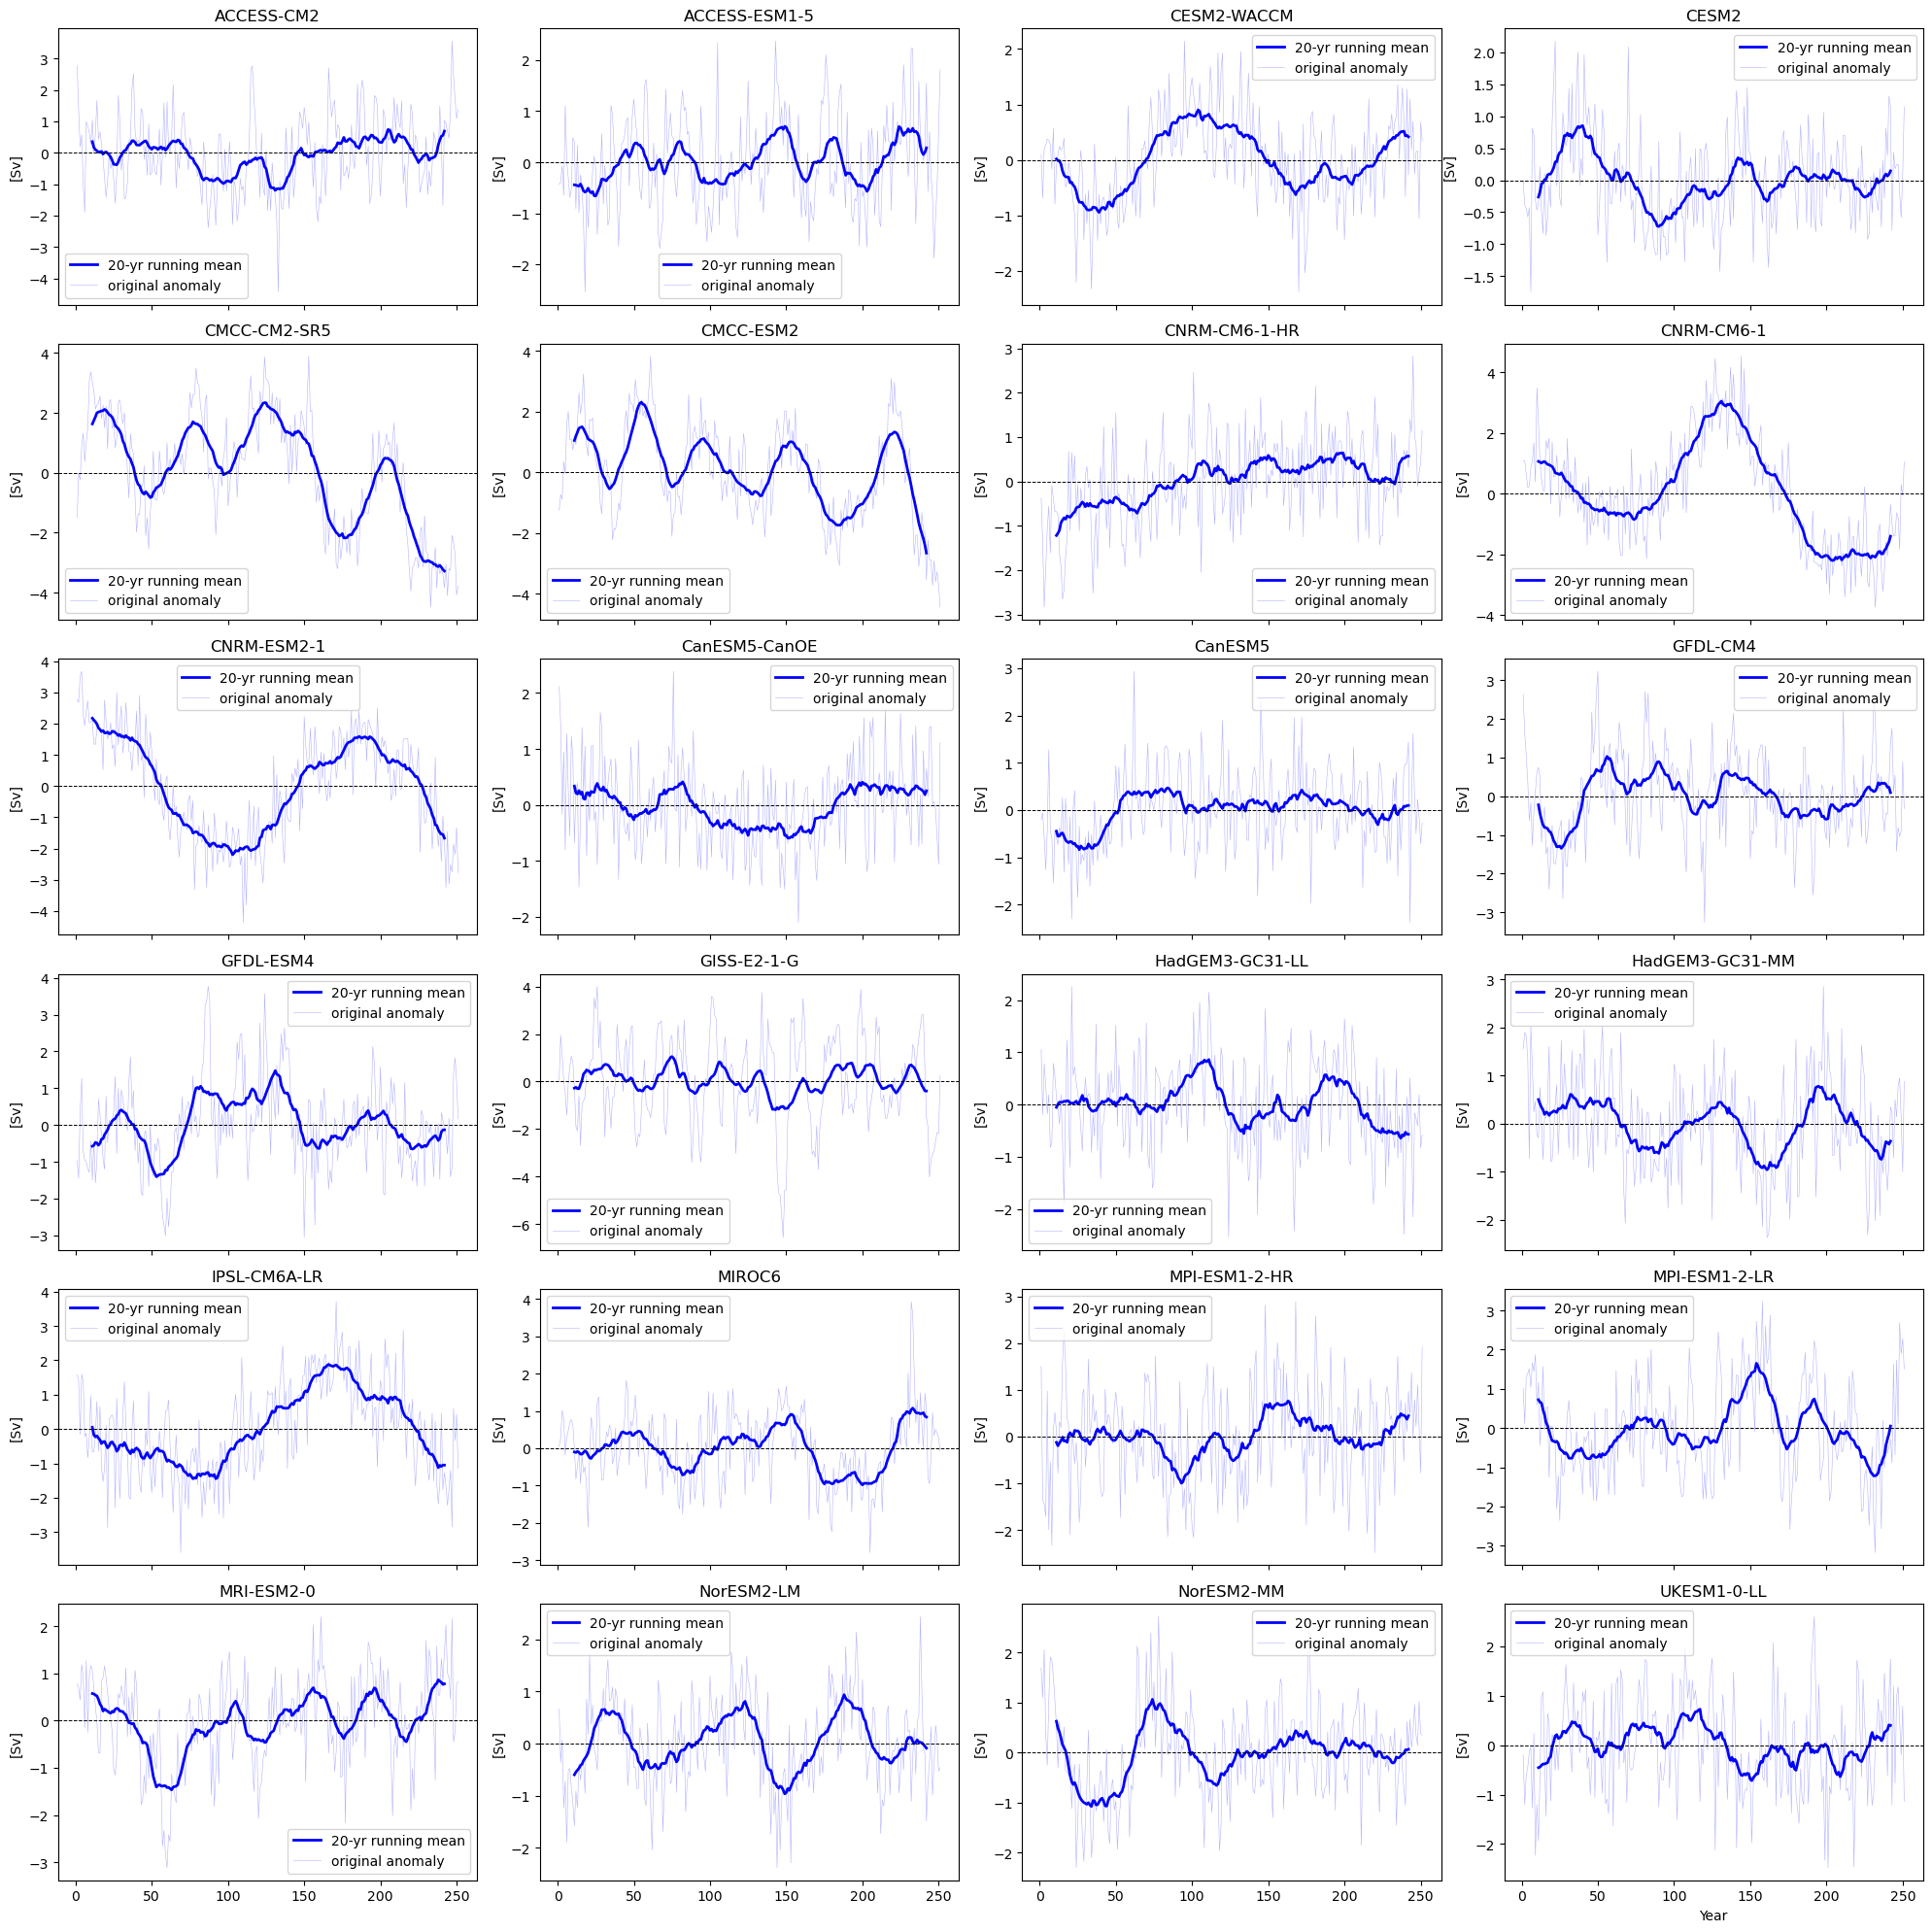

In [3]:
var_name = 'amoc'
amoc_data = {}  # 

fig, axes = plt.subplots(6,4, figsize=(20,20), sharex=True)
axes = axes.flatten()

if len(model_names) == 1:
    axes = [axes]  # Ensure axes is always iterable

for i, model in enumerate(model_names):
    filename_amoc = (
        PATH_AMOC
        + 'amoc_'
        + scenario + '_'
        + amoc_institution_names[i]
        + '_'
        + model
        + '_'
        + ens_members_appendices[i]
        + '.nc'
    )

    ds = xr.open_dataset(filename_amoc, decode_times=False)
    amoc_time_series = ds[var_name]

    # Mean and anomalies
    amoc_mean = amoc_time_series.mean('year')
    amoc_time_series['year'] = xr.DataArray(np.arange(1, len(amoc_time_series['year'].values) + 1), dims='year')
    
    anomaly = amoc_time_series - amoc_mean

    # 20-year running mean
    amoc_smoothed = anomaly.rolling(year=running_mean_window, center=True, min_periods=running_mean_window).mean()

    amoc_smoothed['year'] = xr.DataArray(np.arange(1, len(amoc_smoothed['year'].values) + 1), dims='year')
    

    # Assign to dict
    amoc_data[model] = amoc_smoothed

    # Plot
    ax = axes[i]
    ax.plot(amoc_smoothed['year'], amoc_smoothed, label = str(running_mean_window) + '-yr running mean', color='blue', linewidth=2)
    ax.plot(amoc_time_series['year'], anomaly, color='blue', alpha=0.3, linewidth=0.4, label='original anomaly')
    ax.axhline(0, color='k', linestyle='--', linewidth=0.7)

    ax.set_ylabel('[Sv]')
    ax.set_title(f"{model}")
    ax.legend()

# Final touch
plt.xlabel("Year")
fig.tight_layout()
plt.show()


# Plot mean SST in the North Atlantic

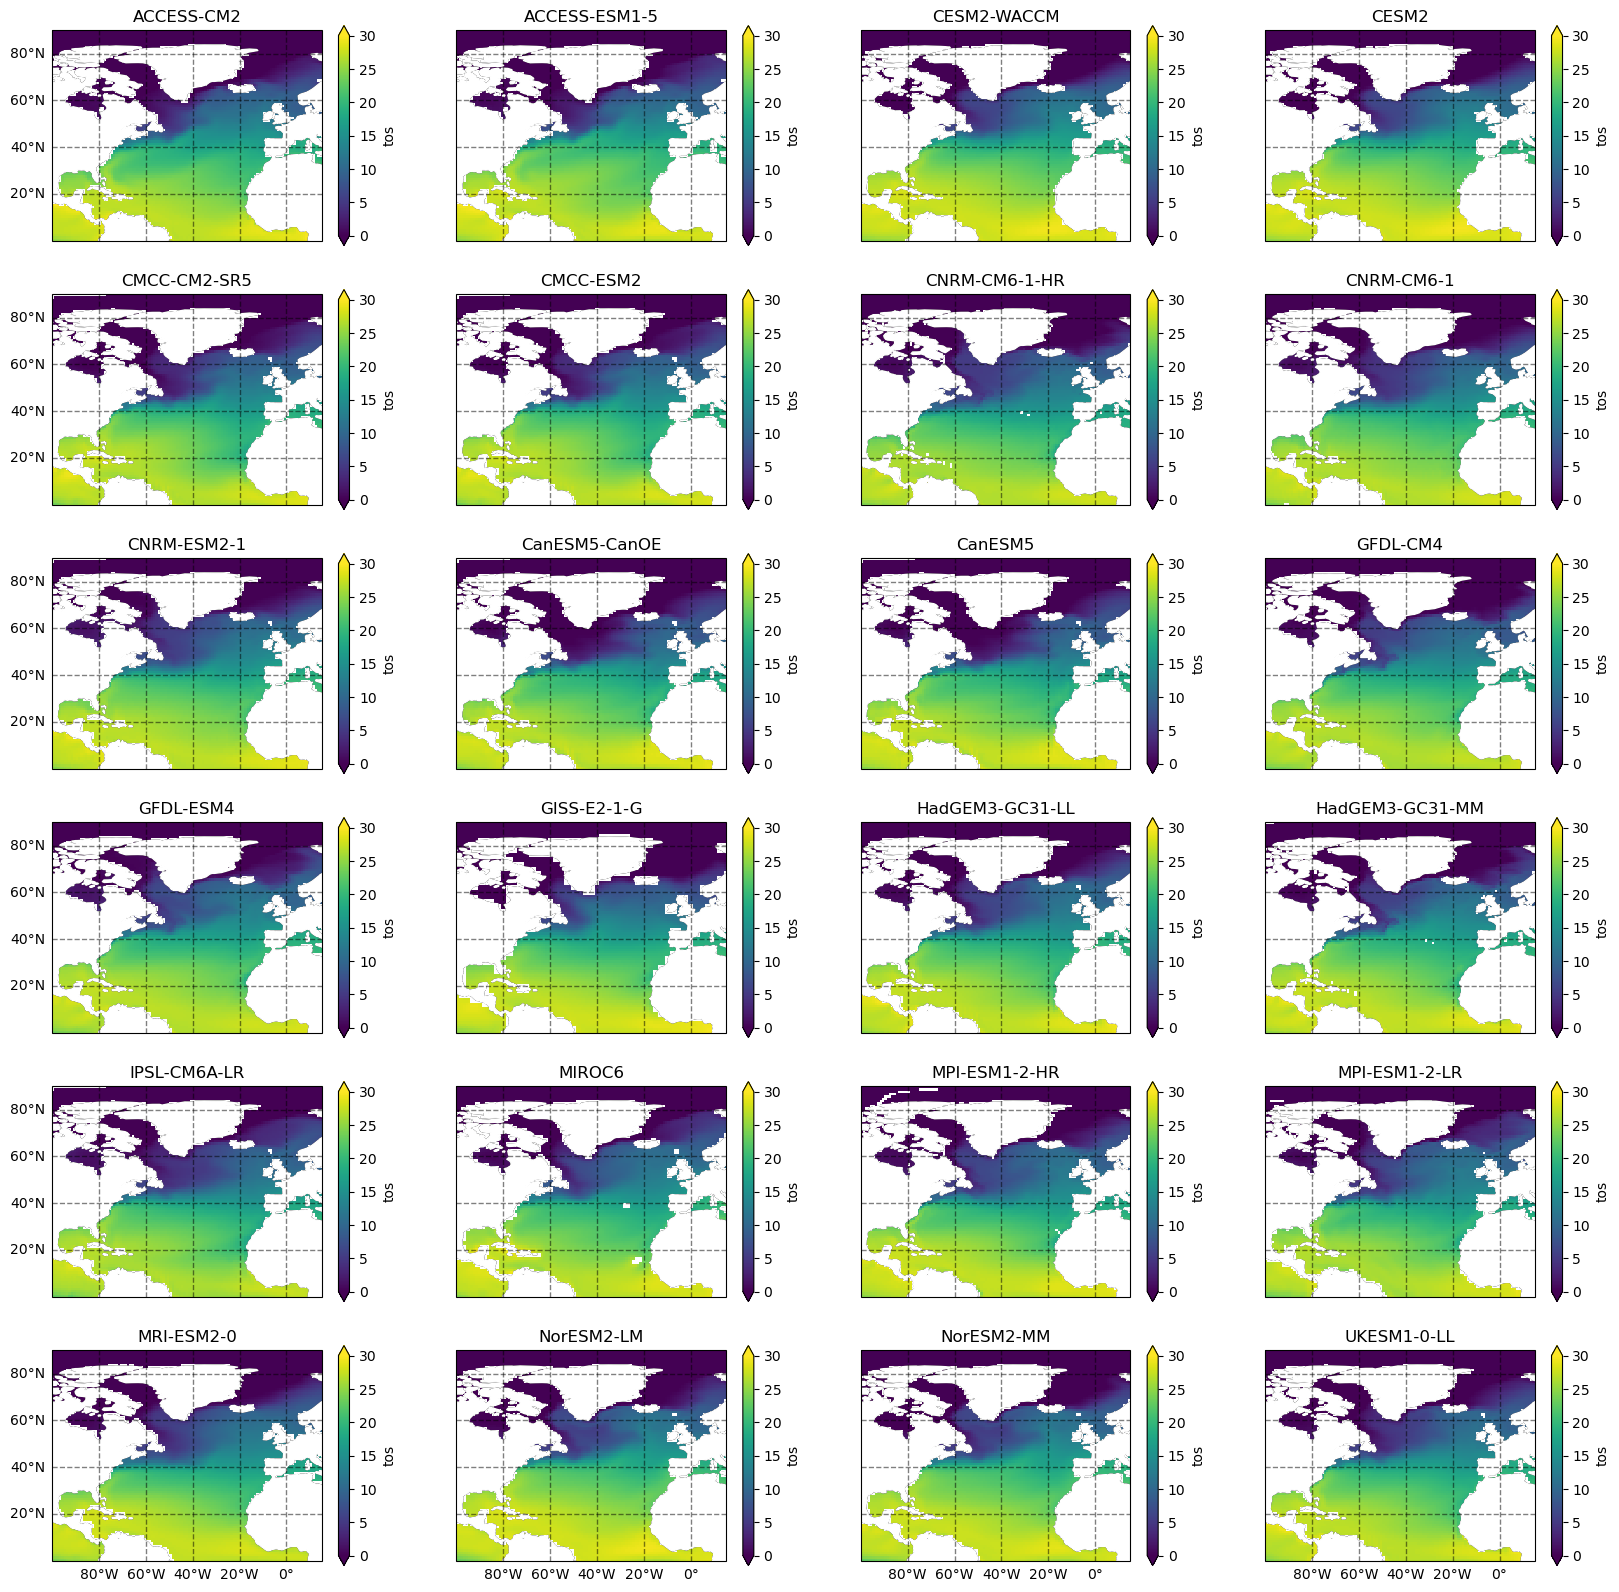

In [4]:
var_name = 'tos'

lat_min = 0
lat_max = 90

lon_min = -100
lon_max = 15

fig, axes = plt.subplots(6, 4, figsize=(20,20), subplot_kw={'projection': ccrs.PlateCarree()}) #, gridspec_kw=gridspec)
axes = axes.ravel()

sst = xr.Dataset()

for i, model in enumerate(model_names):
    filename_sst = PATH_SST + 'tos_Omon_' + model + '_' + scenario + '_' + ens_members_appendices[i] + '.nc'
    if os.path.exists(filename_sst):
        # print(filename_sst)

        sst_time_series = xr.open_dataset(filename_sst)[var_name].sel(lat = slice(lat_min, lat_max), lon = slice(lon_min, lon_max))
        sst_time_series['year'] = xr.DataArray(np.arange(1, len(sst_time_series['year'].values)+1), dims = 'year')

        sst_mean = sst_time_series.mean('year')
        sst_smoothed = (sst_time_series - sst_mean).rolling(year=running_mean_window, center=True).mean()

        sst[model] = sst_smoothed
        
        # print(sst)

        # if model == 'CESM2-WACCM':
        im=sst_mean.plot.pcolormesh(ax=axes[i],  transform=ccrs.PlateCarree(), x='lon', y='lat', extend = 'both', cmap='viridis', vmin = 0, vmax = 30, add_colorbar=True, shading='auto')  
        # else:
        #     im=sst_mean.plot.pcolormesh(ax=axes[i],  transform=ccrs.PlateCarree(), x='longitude', y='latitude', extend = 'both', cmap='viridis', vmin = 0, vmax = 30, add_colorbar=True, shading='auto')  
        
        axes[i].set_title(f"{model}")
        axes[i].coastlines()
        
        land = cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                            edgecolor='face',
                                            facecolor='white')
        axes[i].add_feature(land)
        
        gl = axes[i].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color='black', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.bottom_labels = False
        gl.left_labels = False
        
        # Enable only for leftmost and bottom row plots
        ncols = 4  # You have 6x4 subplots
        nrows = 6
        
        row = i // ncols
        col = i % ncols
        
        if col == 0:
            gl.left_labels = True
        if row == nrows - 1:
            gl.bottom_labels = True
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        
plt.show(im)
# plt.xlabel('year')
fig.tight_layout()
# plt.savefig(f"{PATH_plots}AHT_OHT_{lat_min}_{lat_max}N_AMOC_{lat_amoc}N_time_series_{scenario}.png")
# plt.show()

# Plot regressions of SST on AMOC 

In [5]:
def compute_regression_ignore_nan(var1, var2):
    # Remove NaN values for both arrays
    mask = ~np.isnan(var1) & ~np.isnan(var2)
    if mask.sum() > 1:  # Check there's enough data to perform regression
        slope, intercept, r_value, p_value, std_err = linregress(var2[mask], var1[mask])
        return slope
    else:
        return np.nan  # Return NaN if insufficient data points after filtering


def compute_regression_with_significance(var1, var2, significance_level=0.05):
    # Remove NaN values for both arrays
    mask = ~np.isnan(var1) & ~np.isnan(var2)
    if mask.sum() > 1:  # Check there's enough data to perform regression
        slope, intercept, r_value, p_value, std_err = linregress(var2[mask], var1[mask])
        if p_value < significance_level:
            return slope  # Return the slope only if significant
        else:
            return np.nan  # Return NaN if the result is not significant
    else:
        return np.nan  # Return NaN if insufficient data points


ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


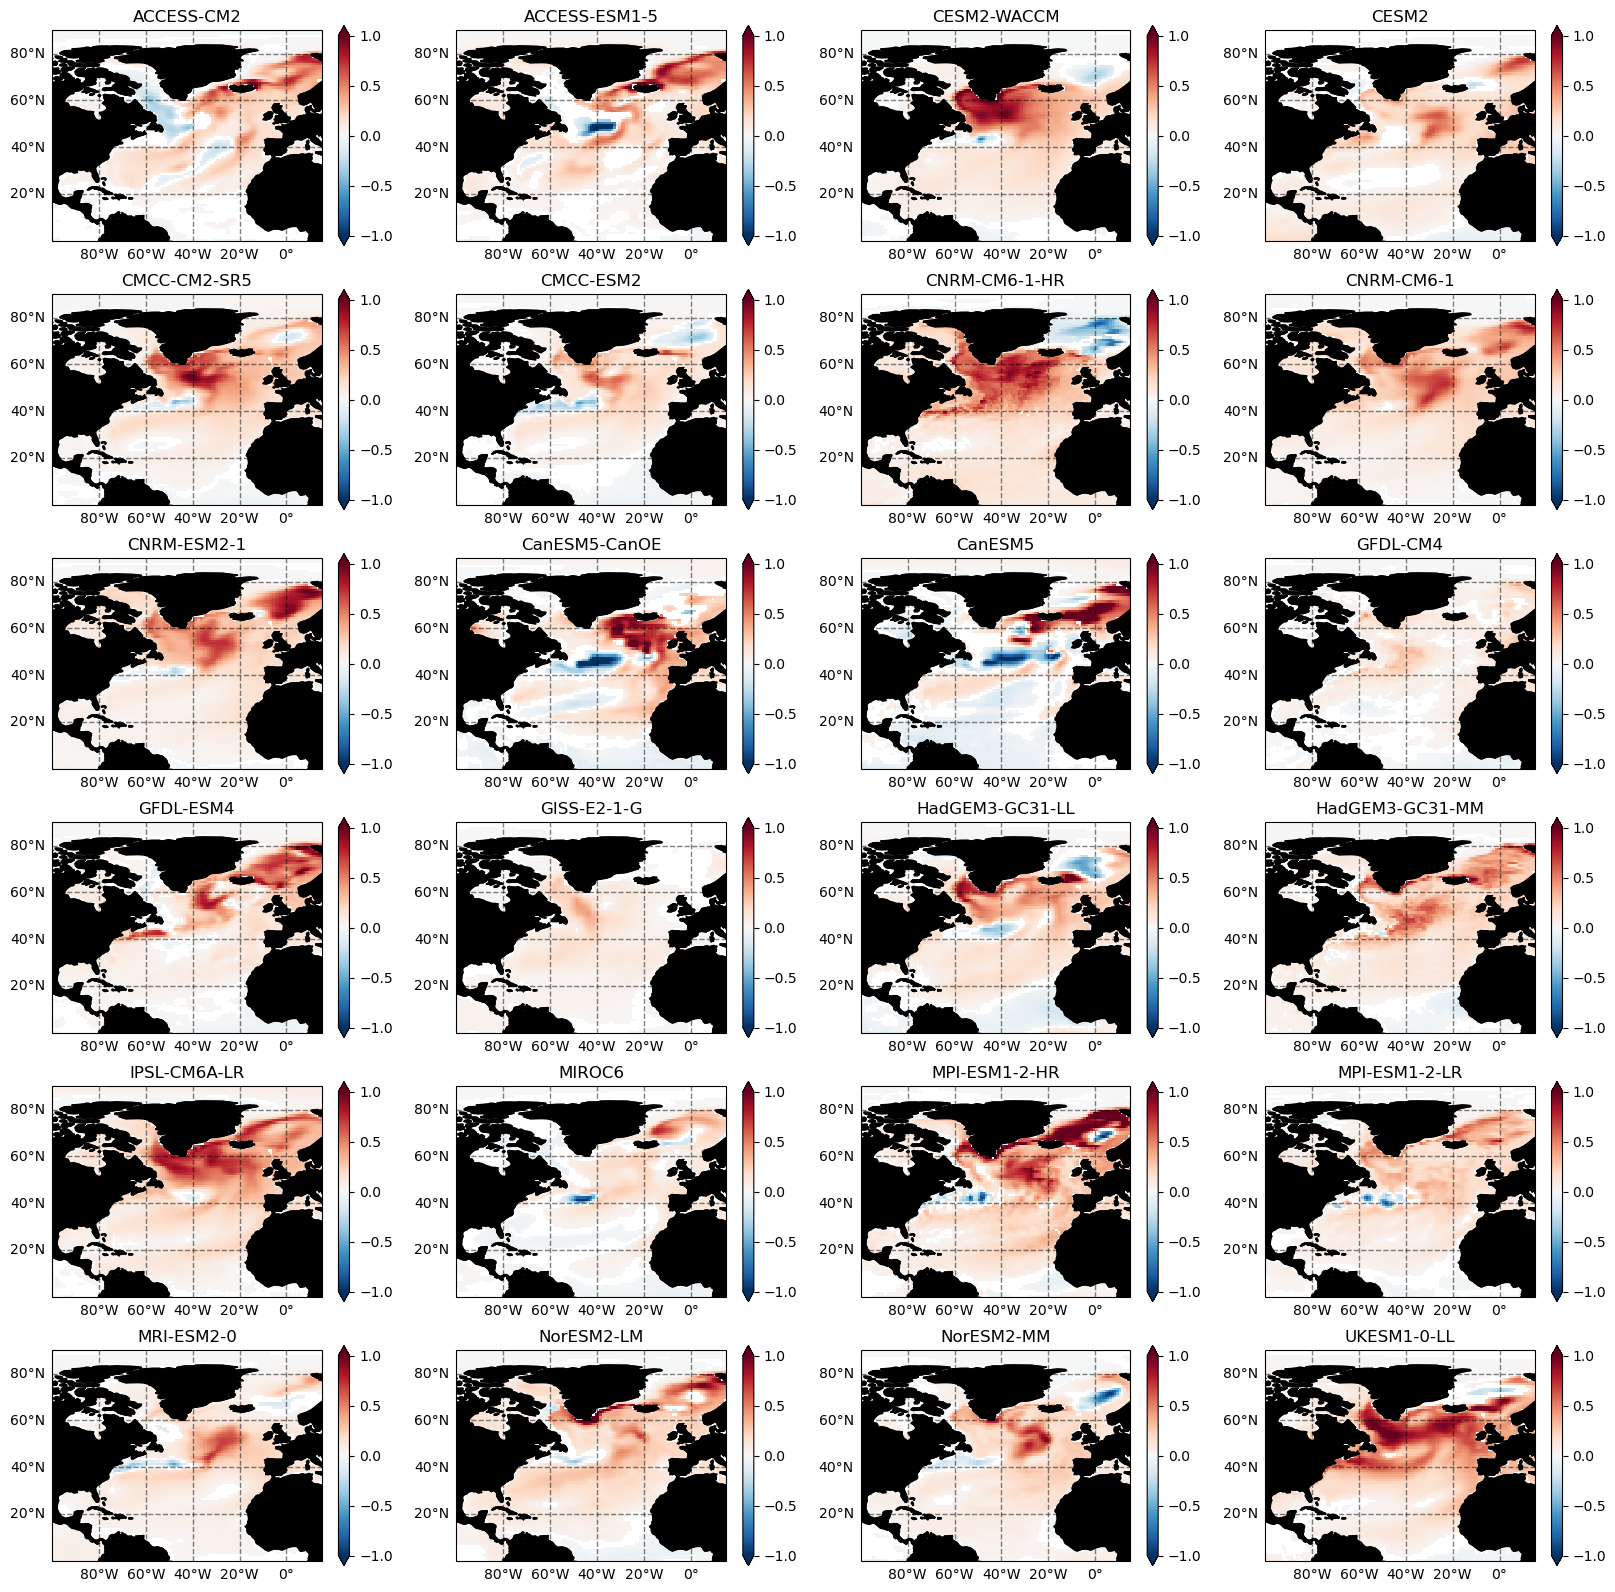

In [6]:
fig, axes = plt.subplots(6, 4, figsize=(20,20), subplot_kw={'projection': ccrs.PlateCarree()}) #, gridspec_kw=gridspec)
axes = axes.ravel()

lat_min = 0
lat_max = 90

lon_min = -100
lon_max = 15


for i, model in enumerate(model_names):
    filename_amoc = PATH_AMOC + 'amoc_' + scenario + '_' + amoc_institution_names[i] + '_' + model + '_' + ens_members_appendices[i] + '.nc'
    filename_sst = PATH_SST + 'tos_Omon_' + model + '_' + scenario + '_' + ens_members_appendices[i] + '.nc'
    if os.path.exists(filename_amoc) and os.path.exists(filename_sst):

        print(model)
        
        sst_time_series = xr.open_dataset(filename_sst)['tos'].sel(lat = slice(lat_min, lat_max), lon = slice(lon_min, lon_max))
        sst_time_series['year'] = xr.DataArray(np.arange(1, len(sst_time_series['year'].values)+1), dims = 'year')
        sst_mean = sst_time_series.mean('year')
        sst_smoothed = (sst_time_series - sst_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')

        sst = sst_smoothed

        if model == 'IPSL-CM6A-LR':
            amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)), x = 0)
        else:
            amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)))
            
        amoc_mean = amoc_time_series.mean('year')
        amoc_smoothed = (amoc_time_series - amoc_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')
        amoc_smoothed['year'] = xr.DataArray(np.arange(1+running_mean_window/2, len(amoc_smoothed['year'].values)+1+running_mean_window/2), dims = 'year')

        amoc = amoc_smoothed

        nx = sst_smoothed.lon.size
        ny = sst_smoothed.lat.size

        regression_slopes = xr.apply_ufunc(
            compute_regression_with_significance,
            sst,                 # 3D DataArray with (time, lat, lon)
            amoc,                 # 1D DataArray with (time)
            input_core_dims=[['year'], ['year']],  # Apply along 'time' axis for both arrays
            vectorize=True        # Vectorize to handle each (lat, lon) independently
        )

        # if model == 'CESM2-WACCM':
        #     regression_slopes['lat'] = sst_smoothed['lat']
        #     regression_slopes['lon'] = sst_smoothed['lon']
        #     im=regression_slopes.plot.pcolormesh(ax=axes[i],  transform=ccrs.PlateCarree(), x='lon', y='lat', extend = 'both', cmap='RdBu_r', vmin = -1, vmax = 1, add_colorbar=True, shading='auto')  
        # else:
        im=regression_slopes.plot.pcolormesh(ax=axes[i],  transform=ccrs.PlateCarree(), x='lon', y='lat', extend = 'both', cmap='RdBu_r', vmin = -1, vmax = 1, add_colorbar=True, shading='auto')  
            
        axes[i].set_title(f"{model}")
        axes[i].coastlines()
        
        land = cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                            edgecolor='face',
                                            facecolor='black')
        axes[i].add_feature(land)

        # Define min and max longitude and latitude
        # lon_min, lon_max = -90, 20   # Replace with desired longitude limits
        # lat_min, lat_max = 0, 90    # Replace with desired latitude limits
        
        # Assuming you have a subplot setup with `axes[i]`
        axes[i].set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

        
        gl = axes[i].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color='black', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        # plot = regression_slopes['NorESM2-MM'].plot()
        # plt.show(plot)
        
        
plt.show(im)
# plt.xlabel('year')
fig.tight_layout()
# plt.show()
# plt.savefig(f"{PATH_plots}SST_AMOC_regression_24models_250years_{scenario}_{running_mean_window}yr_smoothing.png")
# plt.show()

# Compute SST-based AMOC reconstructions for each individual model 

In [7]:
def prepare_and_normalize_sst(sst):
    """
    Prepare SST by subsetting to North Atlantic, filling NaNs, stacking spatial points, and normalizing.
    """
    sst_selected = sst.fillna(0).stack(spatial=("lat", "lon")).values

    # Normalize SST per spatial point
    sst_mean = np.mean(sst_selected, axis=0)
    sst_std = np.std(sst_selected, axis=0)
    sst_std[sst_std == 0] = 1  # Avoid division by zero
    return (sst_selected - sst_mean) / sst_std

def prepare_and_normalize_amoc(amoc):
    """
    Prepare AMOC by subsetting, filling NaNs, and normalizing.
    """
    amoc_selected = amoc.fillna(0).values
    amoc_mean = np.mean(amoc_selected)
    amoc_std = np.std(amoc_selected)
    return amoc_selected, (amoc_selected - amoc_mean) / amoc_std, amoc_mean, amoc_std

def train_regression_and_reconstruct(sst_normalized, amoc, amoc_std):
    """
    Train regression (compute f) and reconstruct AMOC using SST.
    """
    f = sst_normalized.T @ amoc / sst_normalized.shape[0]
    amoc_reconstructed = sst_normalized @ f
    amoc_reconstructed = amoc_reconstructed * amoc_std / np.std(amoc_reconstructed)  # Rescale
    return f, amoc_reconstructed

def save_regression_map_sst_amoc_to_file(f, ny, nx, sst_for_coords, sst_norm, amoc_norm, amoc_std, amoc_recon, model_name, path_output, smoothing_period = 20):
    """
    Saves regression map to file, including:
    - fr (masked regression coefficients)
    - normalized SST (same shape as fr)
    - AMOC time series (1D, yearly values)
    """

    # Reshape `f` to (ny, nx) and mask land areas (0 → NaN)
    fr = np.reshape(f, [ny, nx])
    fr_masked = np.where(fr == 0, np.nan, fr)

    # Extract coordinates
    lat = sst_for_coords["lat"]  # (j, i)
    lon = sst_for_coords["lon"]  # (j, i)
    # i_coord = sst_normalised["i"]  # (i)
    # j_coord = sst_normalised["j"]  # (j)

    # # Ensure `fr` has the correct shape
    # assert fr.shape == (len(j_coord), len(i_coord)), "Shape mismatch!"

    # Create DataArray for `fr`
    fr_dataarray = xr.DataArray(
        fr_masked, 
        coords={"lat": lat, "lon": lon}, 
        dims=["lat", "lon"], 
        name="fr"
    )

    
    # # Assign latitude and longitude
    # fr_dataarray = fr_dataarray.assign_coords(latitude=(("j", "i"), lat.values))
    # fr_dataarray = fr_dataarray.assign_coords(longitude=(("j", "i"), lon.values))

    # === Normalized SST  ===

    sst_masked = np.where(sst_norm == 0, np.nan, sst_norm)

    sst_reshaped = sst_masked.reshape(251 - smoothing_period, ny, nx)
        
    sst_dataarray = xr.DataArray(
        sst_reshaped,
        coords={"year": np.arange(1 + smoothing_period/2, 251 - smoothing_period/2 + 1), "lat": lat, "lon": lon},
        dims=["year", "lat", "lon"],
        name="sst_normalized"
    )
    
    # # Assign latitude and longitude to SST

    # sst_dataarray = sst_dataarray.assign_coords(latitude=(("j", "i"), lat.values))
    # sst_dataarray = sst_dataarray.assign_coords(longitude=(("j", "i"), lon.values))

    # === AMOC Time Series (Yearly Data from period_start to period_end) ===
    years = np.arange(1 + smoothing_period/2, 251 - smoothing_period/2 + 1)
    assert len(amoc_norm) == len(years), "AMOC (normalised) time series length mismatch!"

    amoc_norm_dataarray = xr.DataArray(
        amoc_norm, 
        coords={"year": years}, 
        dims=["year"], 
        name="amoc"
    )

    amoc_std_dataarray = xr.DataArray(
        amoc_std, 
        name="amoc"
    )

    assert len(amoc_recon) == len(years), "AMOC (reconstructed) time series length mismatch!"

    amoc_recon_dataarray = xr.DataArray(
        amoc_recon, 
        coords={"year": years}, 
        dims=["year"], 
        name="amoc"
    )
    
    # === Merge into a dataset and save ===
    dataset = xr.Dataset({"fr": fr_dataarray, "normalized_sst": sst_dataarray, "amoc_normalised": amoc_norm_dataarray, "amoc_std": amoc_std_dataarray, "amoc_reconstructed": amoc_recon_dataarray})

    # Define output filename
    output_filename = f"{model_name}_{251 - smoothing_period}yrs.nc"

    # Save to NetCDF
    dataset.to_netcdf(path_output + output_filename)
    print(f"Saved to {path_output + output_filename}")





def plot_regression_coefficients(f, ny, nx, title):
    """
    Reshape and plot regression coefficients with land masked as NaN.
    """
    fr = np.reshape(f, [ny, nx])
    fr_masked = np.where(fr == 0, np.nan, fr)
    plt.figure(figsize=(8, 6))

    if model_names[0]=='MPI-ESM1-2-HR':
        fr_masked = np.flipud(fr_masked)
        
    plt.contourf(fr_masked, cmap="viridis", levels=20)
    plt.colorbar(label="Regression Coefficients")
    plt.title(title)
    plt.show()

def plot_amoc_comparison(amoc_original, amoc_reconstructed, title, smoothing_period = 20):
    """
    Plot original vs reconstructed AMOC.
    """
    years = np.arange(1 + smoothing_period/2, 251 - smoothing_period/2 + 1)
    amoc_original_da = xr.DataArray(amoc_original, dims='year', coords={'year': years})
    amoc_reconstructed_da = xr.DataArray(amoc_reconstructed, dims='year', coords={'year': years})
    
    plt.figure(figsize=(8, 5))
    amoc_original_da.plot(label="Original AMOC", linewidth=2)
    amoc_reconstructed_da.plot(label="Reconstructed AMOC", linestyle="--", linewidth=2)
    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel("AMOC [Sv]")
    plt.legend()
    plt.show()

# Plotting regressions and saving them to files 

ACCESS-CM2
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/ACCESS-CM2_231yrs.nc


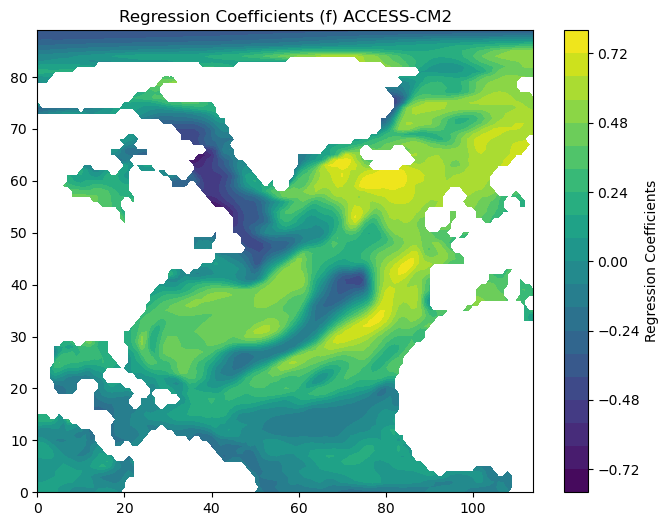

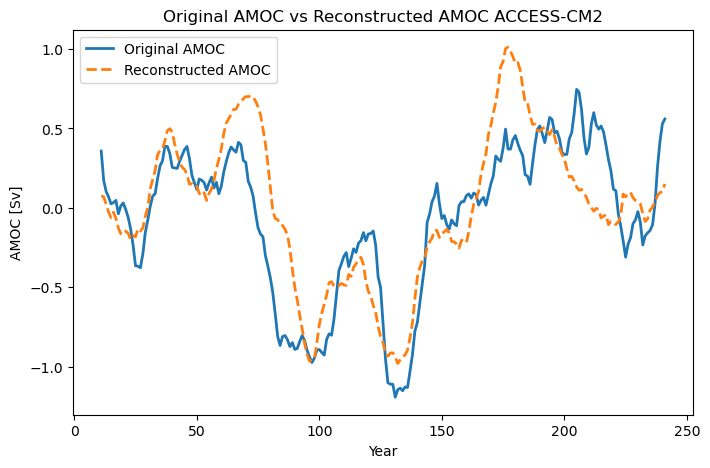

f range: -0.7406 to 0.7991
AMOC range: -1.1921 to 0.7459
Reconstructed AMOC range: -0.9799 to 1.0112
ACCESS-ESM1-5
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/ACCESS-ESM1-5_231yrs.nc


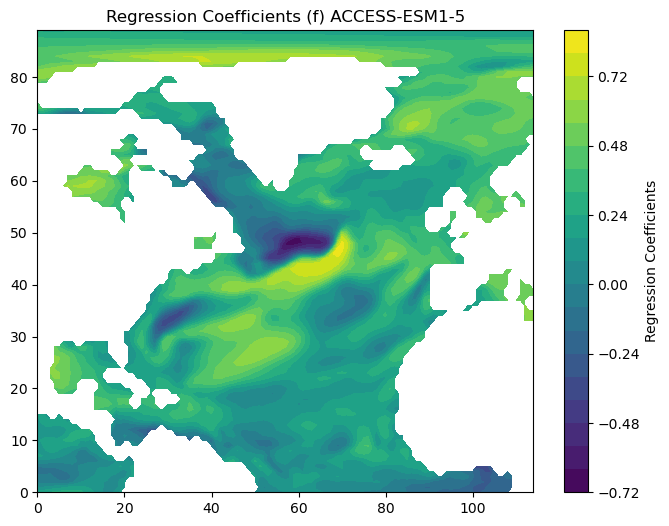

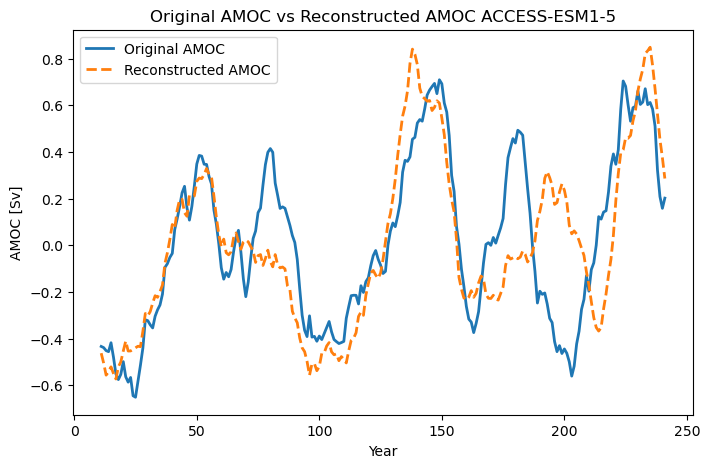

f range: -0.6921 to 0.8232
AMOC range: -0.6515 to 0.7097
Reconstructed AMOC range: -0.5733 to 0.8492
CESM2-WACCM
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/CESM2-WACCM_231yrs.nc


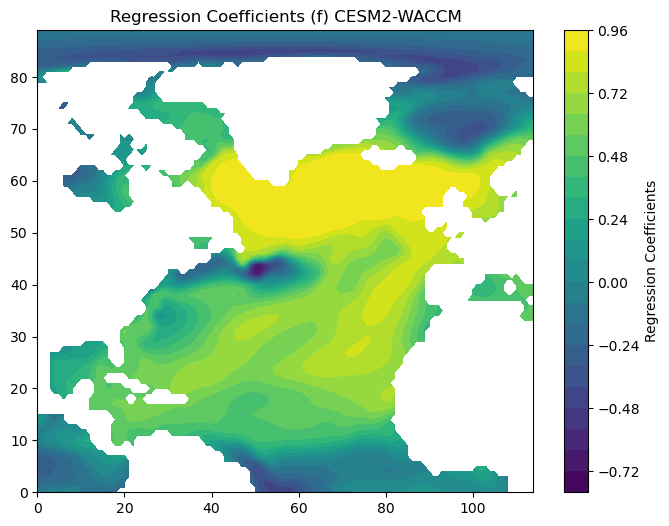

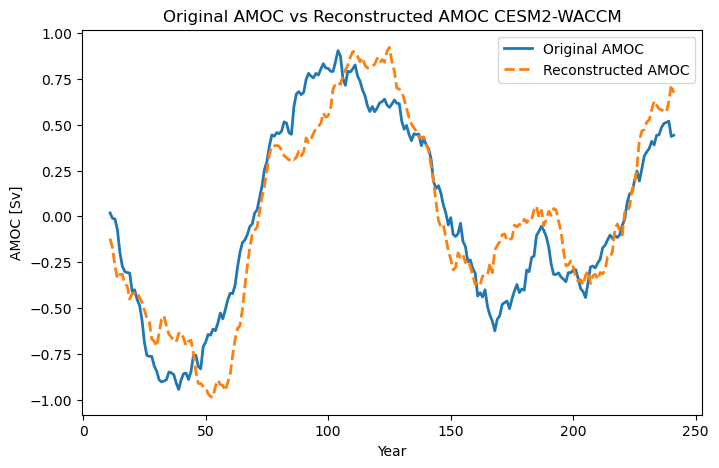

f range: -0.7263 to 0.9499
AMOC range: -0.9446 to 0.9048
Reconstructed AMOC range: -0.9874 to 0.9236
CESM2
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/CESM2_231yrs.nc


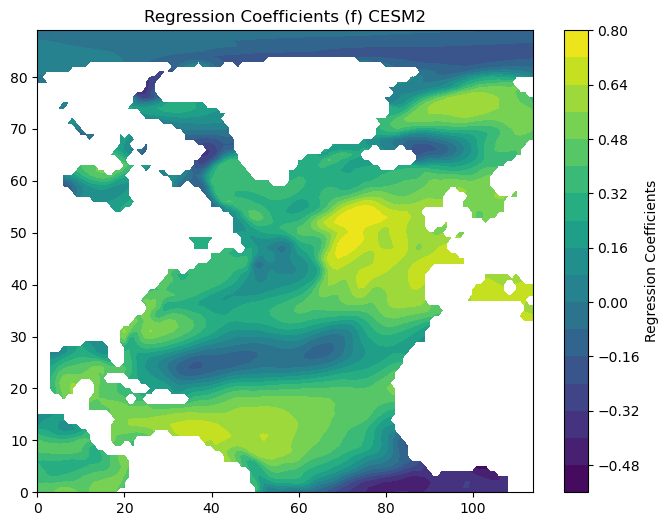

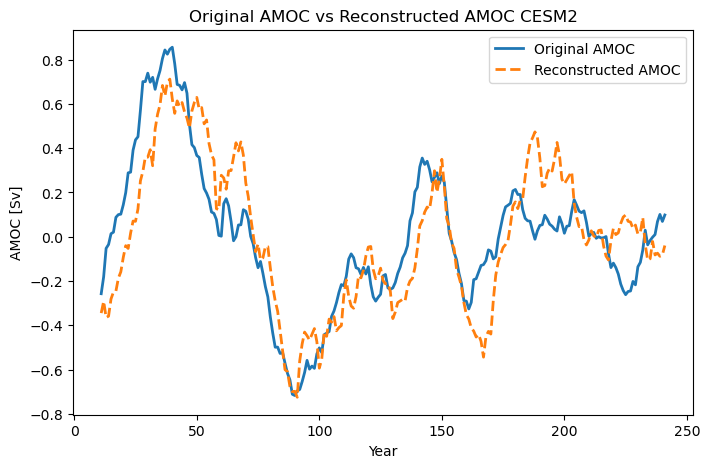

f range: -0.5240 to 0.7781
AMOC range: -0.7175 to 0.8561
Reconstructed AMOC range: -0.7252 to 0.7121
CMCC-CM2-SR5
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/CMCC-CM2-SR5_231yrs.nc


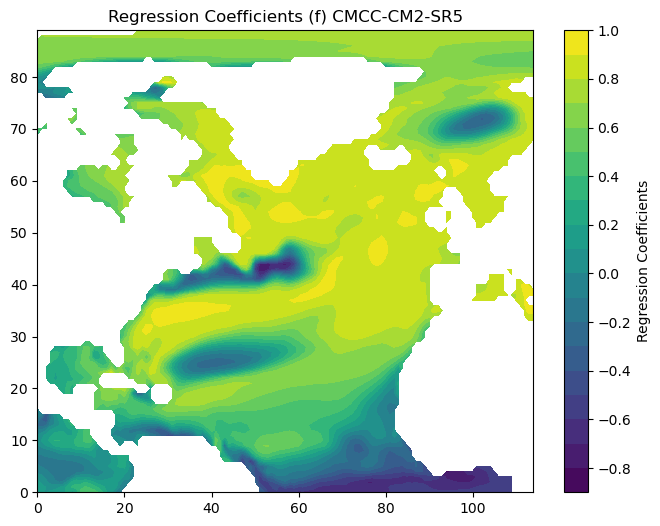

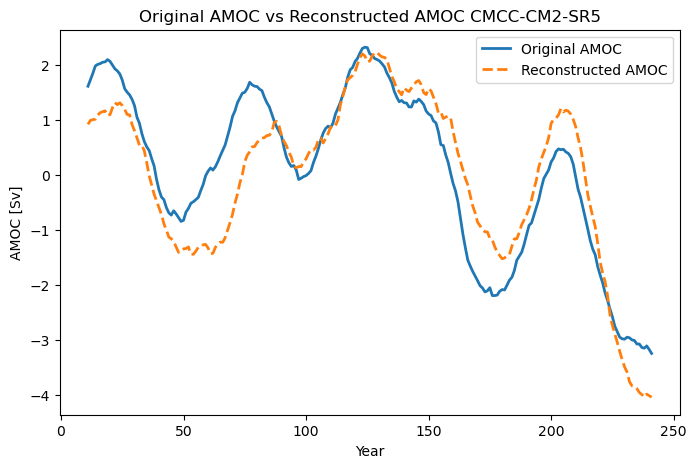

f range: -0.8311 to 0.9422
AMOC range: -3.2411 to 2.3273
Reconstructed AMOC range: -4.0376 to 2.2317
CMCC-ESM2
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/CMCC-ESM2_231yrs.nc


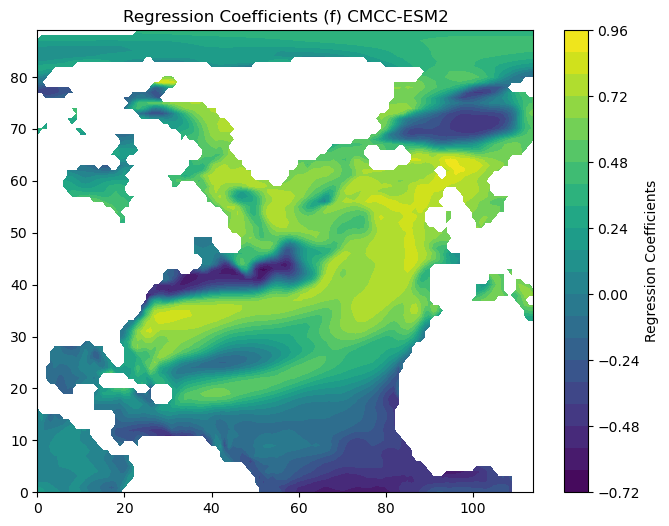

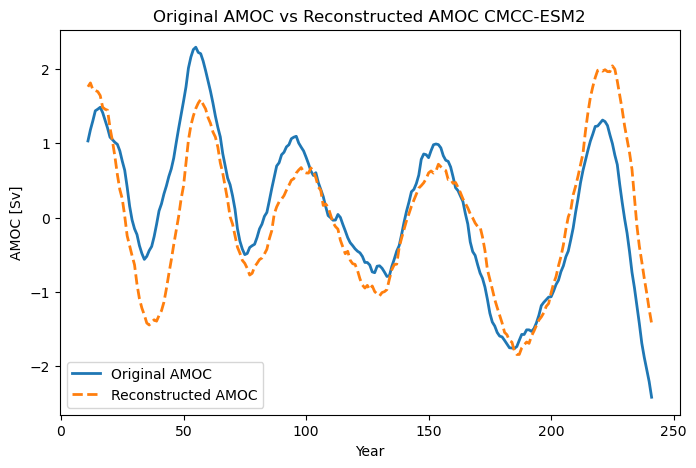

f range: -0.6809 to 0.9126
AMOC range: -2.4157 to 2.2937
Reconstructed AMOC range: -1.8410 to 2.0432
CNRM-CM6-1-HR
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/CNRM-CM6-1-HR_231yrs.nc


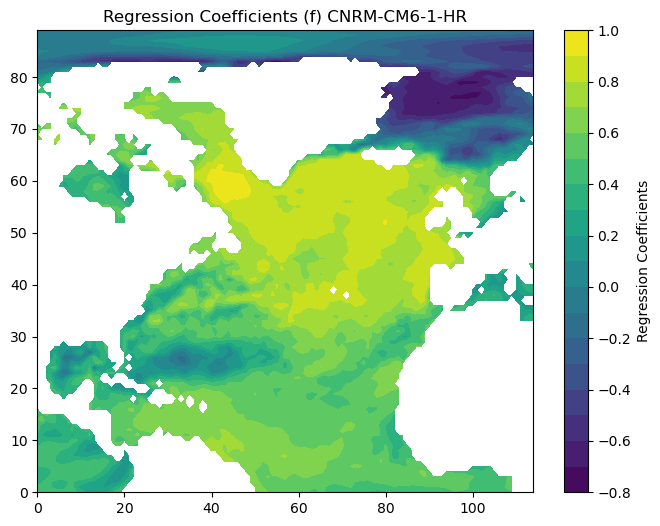

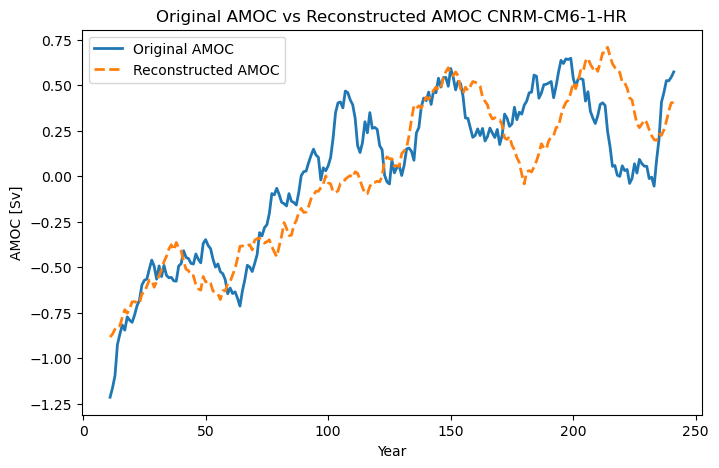

f range: -0.7713 to 0.9287
AMOC range: -1.2146 to 0.6484
Reconstructed AMOC range: -0.8840 to 0.7090
CNRM-CM6-1
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/CNRM-CM6-1_231yrs.nc


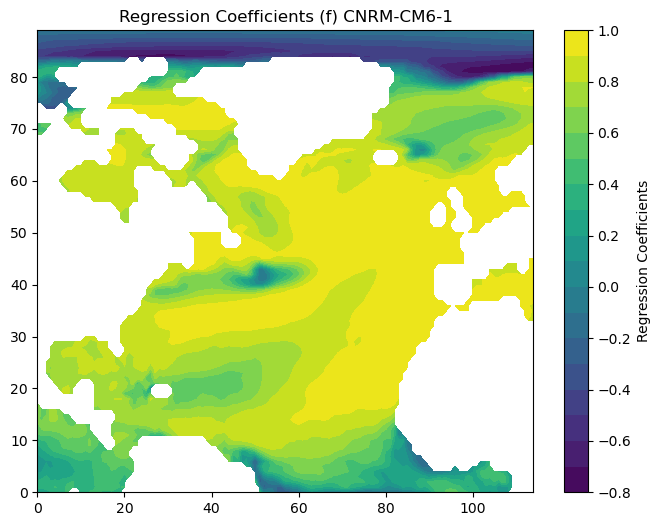

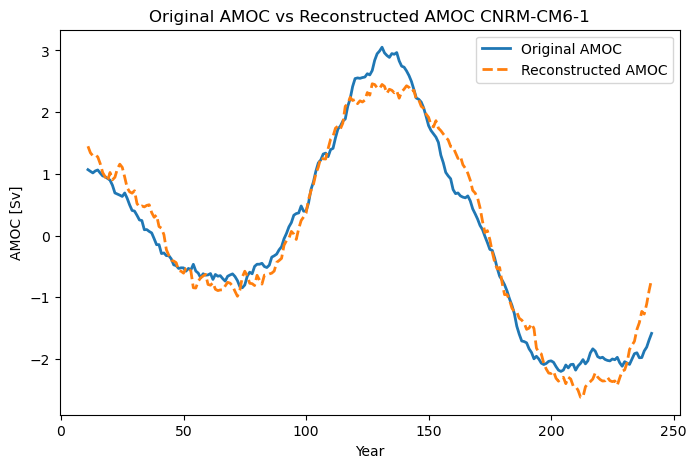

f range: -0.7960 to 0.9859
AMOC range: -2.2007 to 3.0513
Reconstructed AMOC range: -2.6189 to 2.4589
CNRM-ESM2-1
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/CNRM-ESM2-1_231yrs.nc


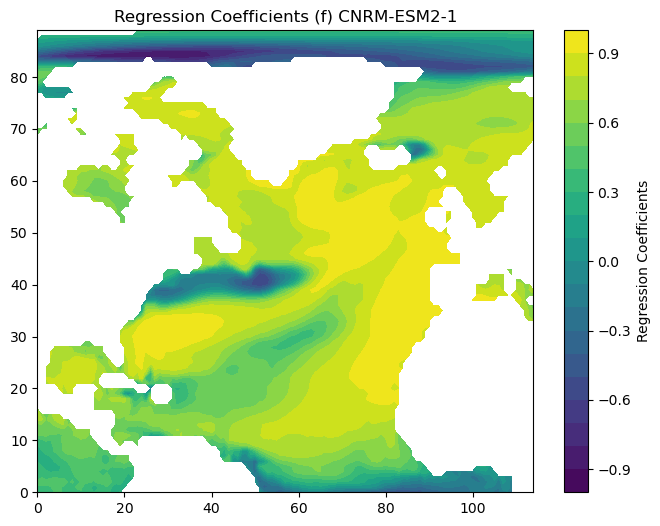

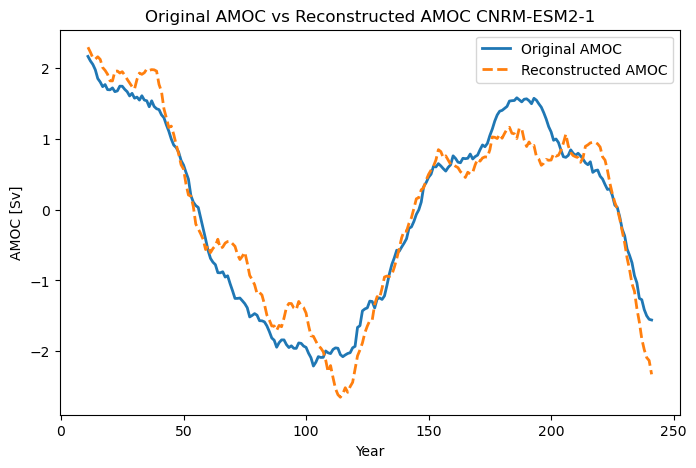

f range: -0.9209 to 0.9730
AMOC range: -2.2094 to 2.1638
Reconstructed AMOC range: -2.6496 to 2.2933
CanESM5-CanOE
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/CanESM5-CanOE_231yrs.nc


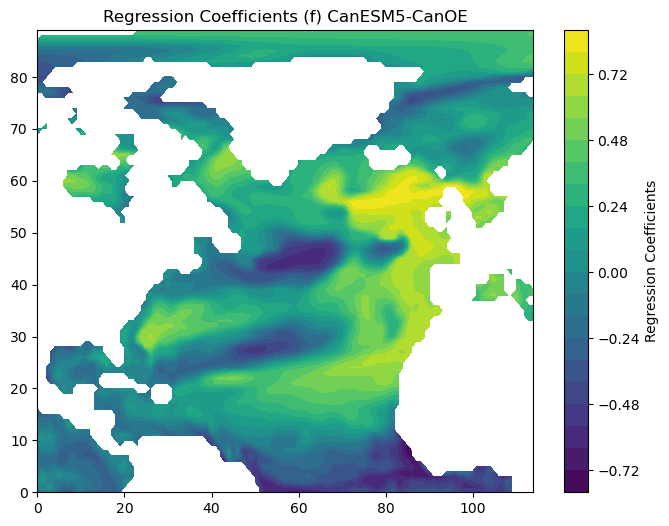

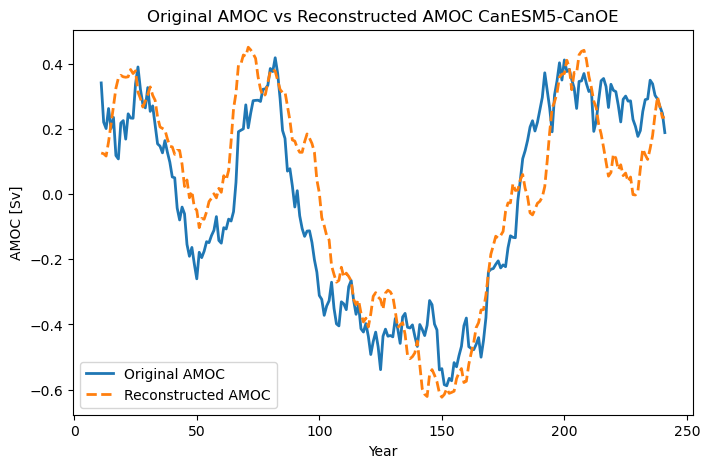

f range: -0.7794 to 0.8553
AMOC range: -0.5882 to 0.4186
Reconstructed AMOC range: -0.6234 to 0.4509
CanESM5
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/CanESM5_231yrs.nc


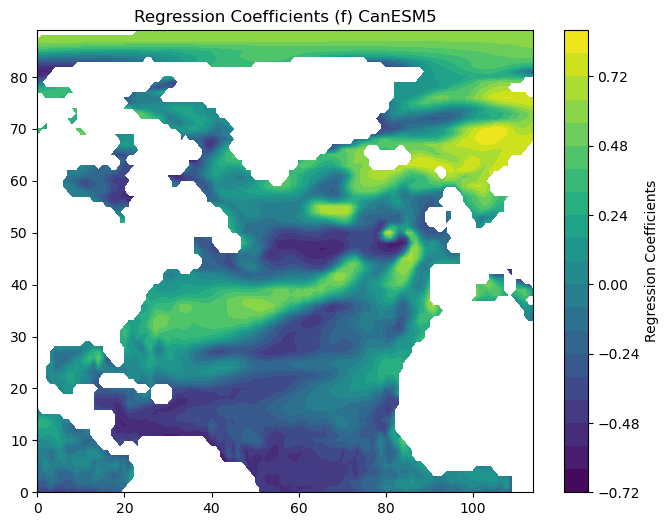

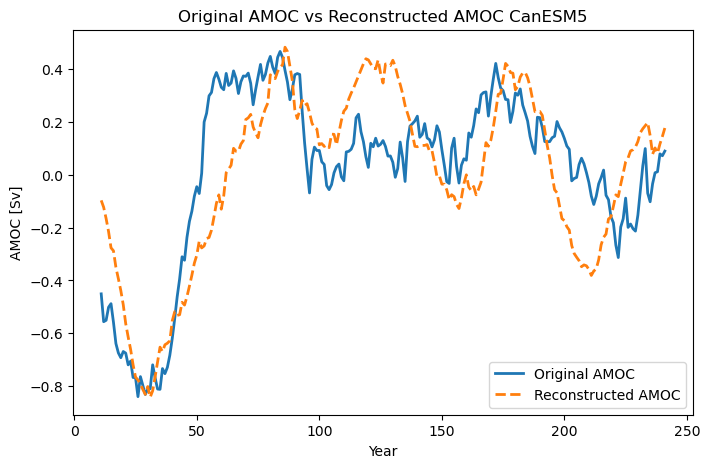

f range: -0.6461 to 0.8740
AMOC range: -0.8399 to 0.4672
Reconstructed AMOC range: -0.8421 to 0.4832
GFDL-CM4
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/GFDL-CM4_231yrs.nc


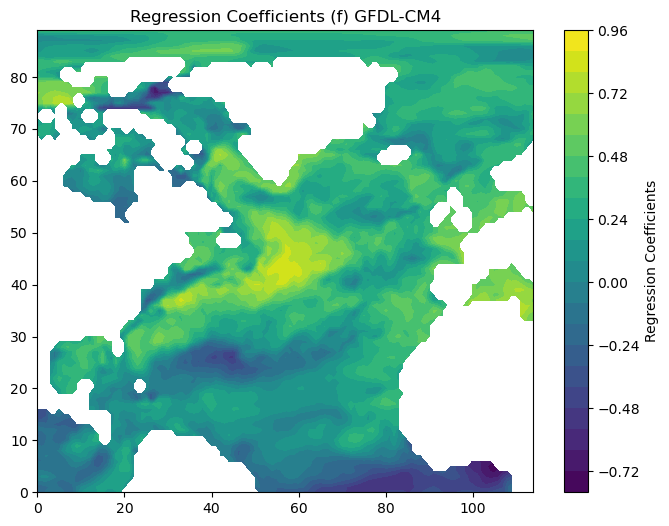

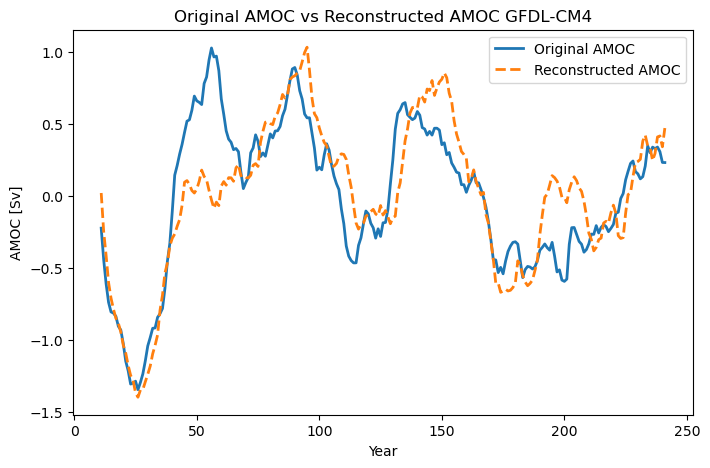

f range: -0.7618 to 0.8801
AMOC range: -1.3469 to 1.0301
Reconstructed AMOC range: -1.3996 to 1.0354
GFDL-ESM4
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/GFDL-ESM4_231yrs.nc


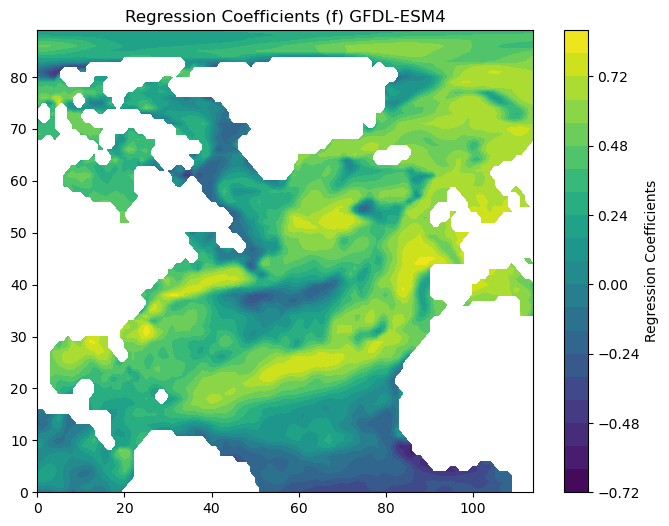

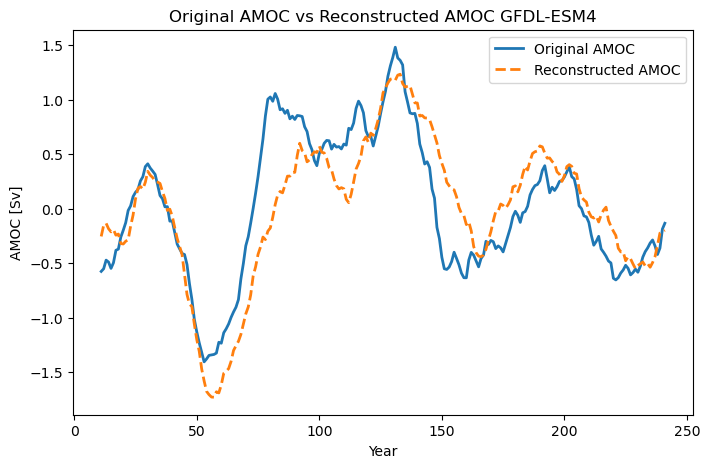

f range: -0.6472 to 0.8288
AMOC range: -1.4040 to 1.4799
Reconstructed AMOC range: -1.7283 to 1.2324
GISS-E2-1-G
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/GISS-E2-1-G_231yrs.nc


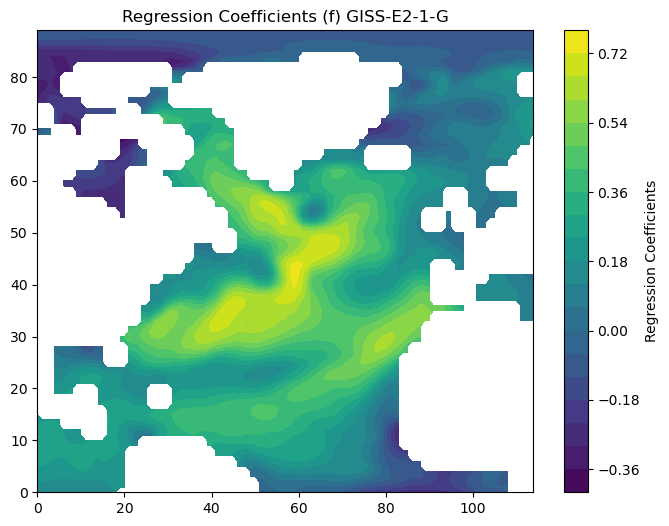

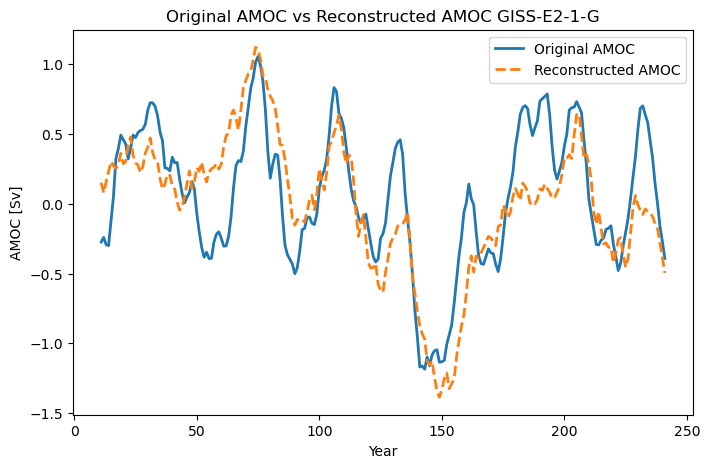

f range: -0.3929 to 0.7397
AMOC range: -1.1854 to 1.0548
Reconstructed AMOC range: -1.3858 to 1.1205
HadGEM3-GC31-LL
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/HadGEM3-GC31-LL_231yrs.nc


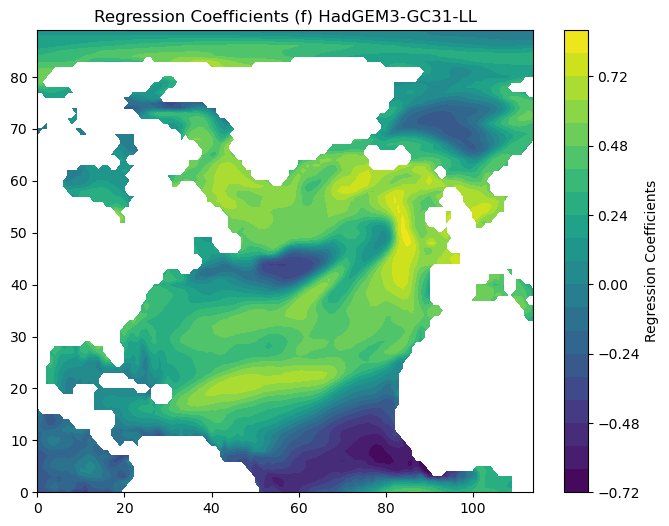

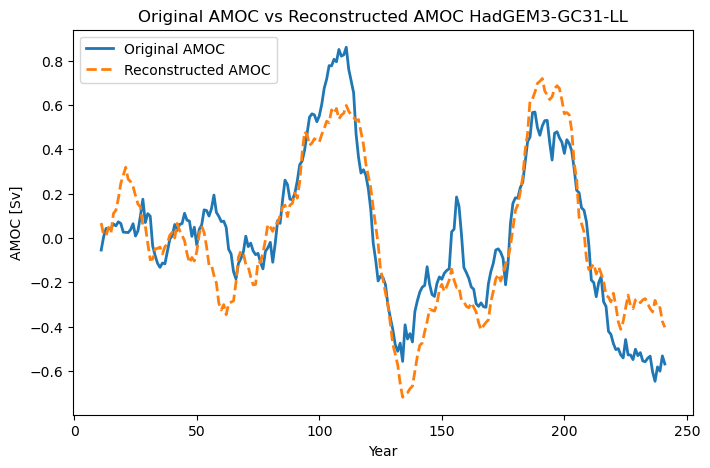

f range: -0.6862 to 0.8293
AMOC range: -0.6461 to 0.8602
Reconstructed AMOC range: -0.7178 to 0.7192
HadGEM3-GC31-MM
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/HadGEM3-GC31-MM_231yrs.nc


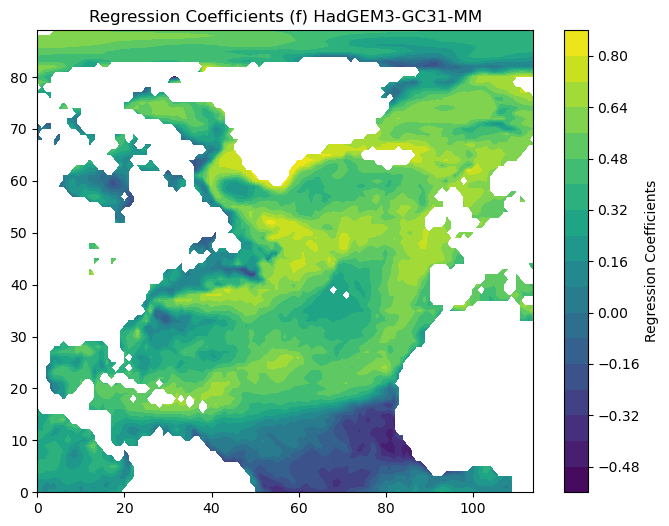

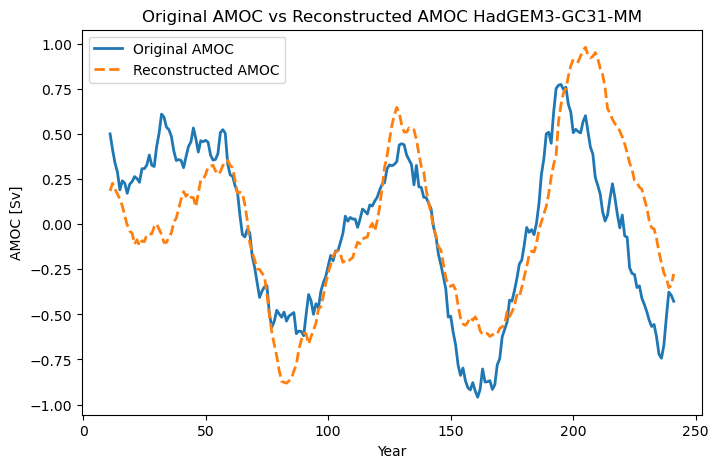

f range: -0.4995 to 0.8459
AMOC range: -0.9595 to 0.7759
Reconstructed AMOC range: -0.8815 to 0.9826
IPSL-CM6A-LR
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/IPSL-CM6A-LR_231yrs.nc


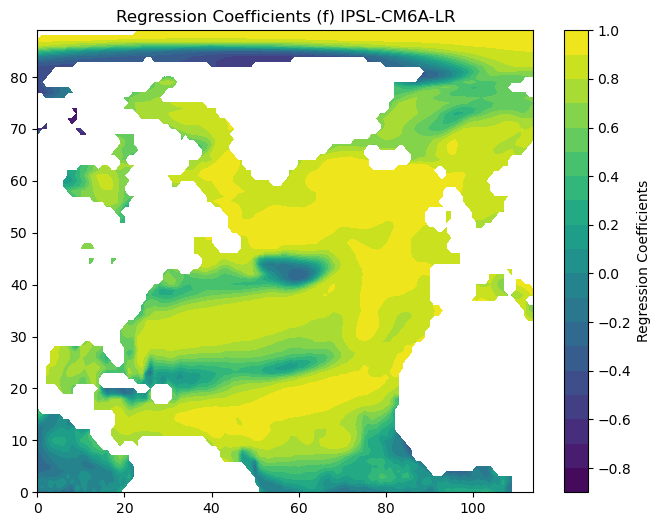

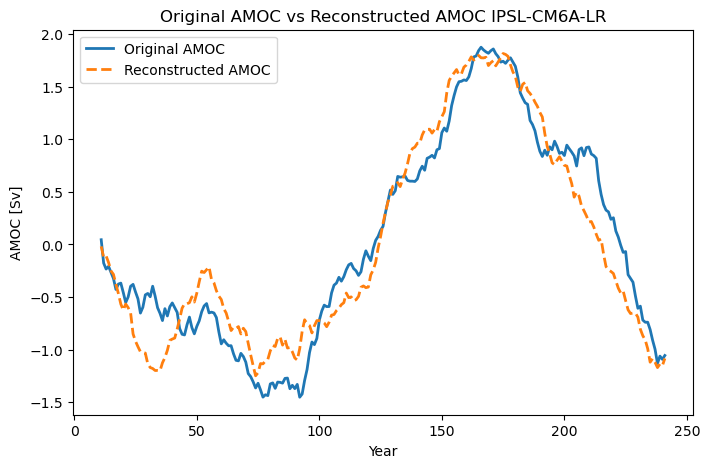

f range: -0.8419 to 0.9612
AMOC range: -1.4533 to 1.8753
Reconstructed AMOC range: -1.2495 to 1.8155
MIROC6
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/MIROC6_231yrs.nc


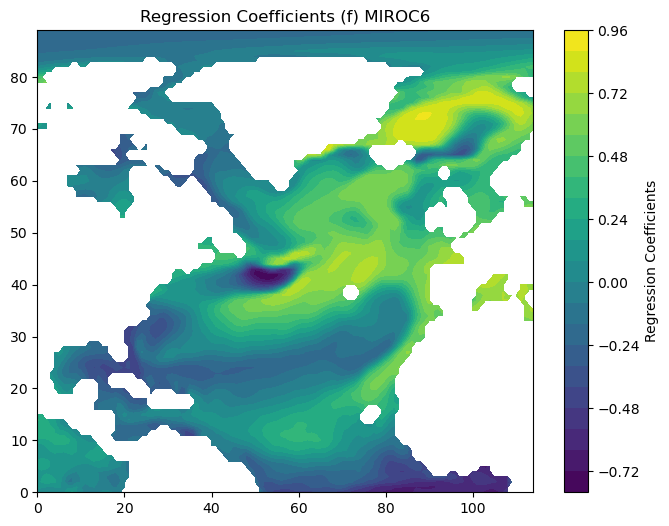

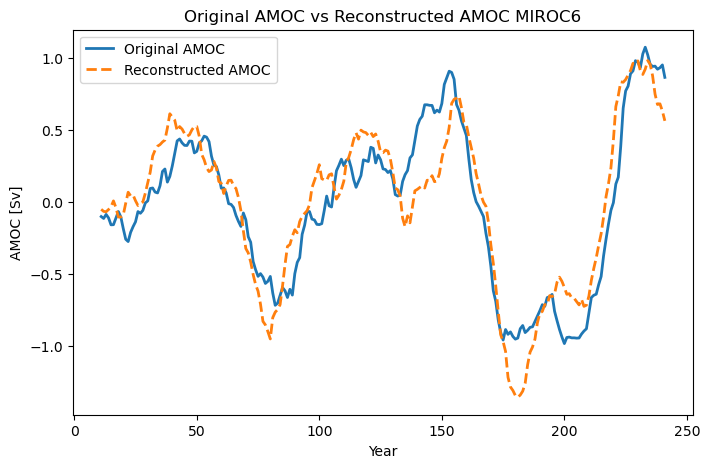

f range: -0.7862 to 0.8877
AMOC range: -0.9830 to 1.0762
Reconstructed AMOC range: -1.3556 to 0.9835
MPI-ESM1-2-HR
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/MPI-ESM1-2-HR_231yrs.nc


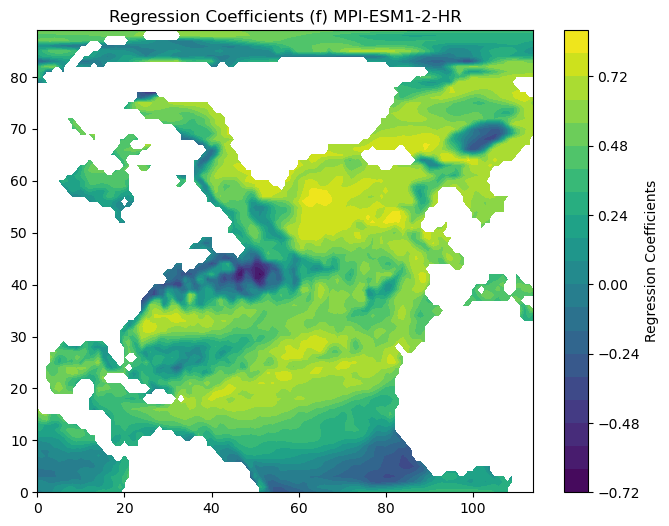

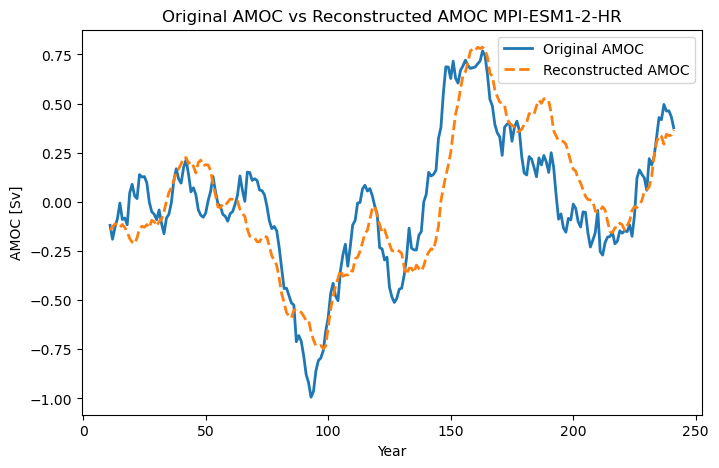

f range: -0.6801 to 0.8490
AMOC range: -0.9936 to 0.7681
Reconstructed AMOC range: -0.7466 to 0.7866
MPI-ESM1-2-LR
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/MPI-ESM1-2-LR_231yrs.nc


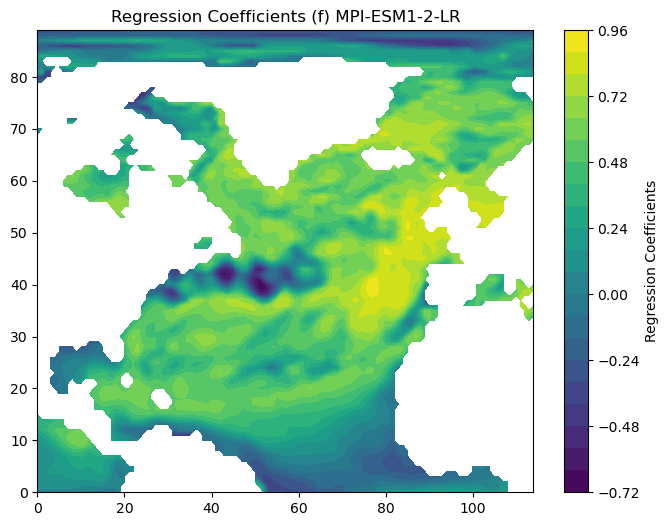

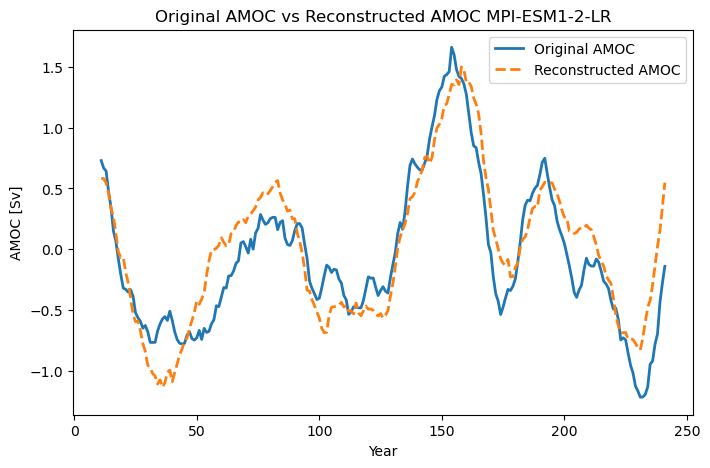

f range: -0.7139 to 0.9047
AMOC range: -1.2135 to 1.6589
Reconstructed AMOC range: -1.1316 to 1.4977
MRI-ESM2-0
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/MRI-ESM2-0_231yrs.nc


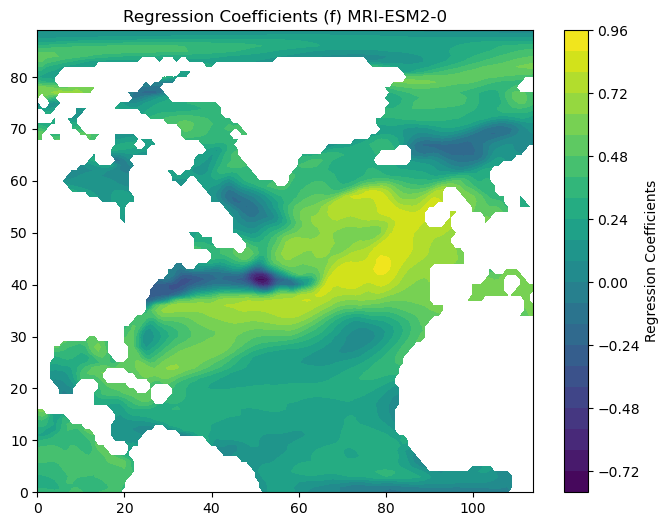

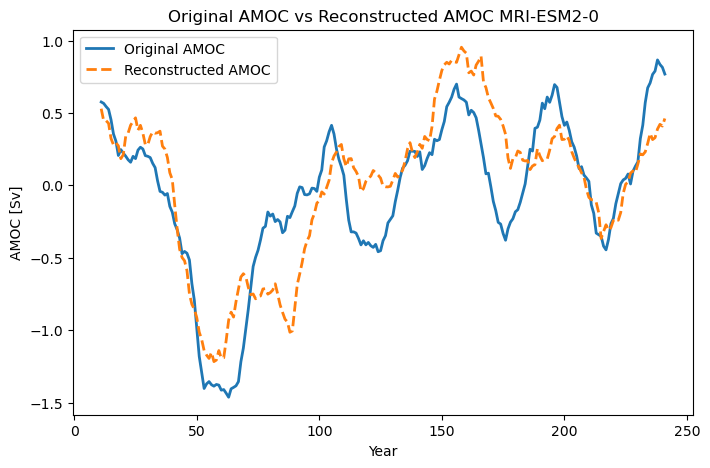

f range: -0.7647 to 0.8931
AMOC range: -1.4634 to 0.8666
Reconstructed AMOC range: -1.2173 to 0.9543
NorESM2-LM
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/NorESM2-LM_231yrs.nc


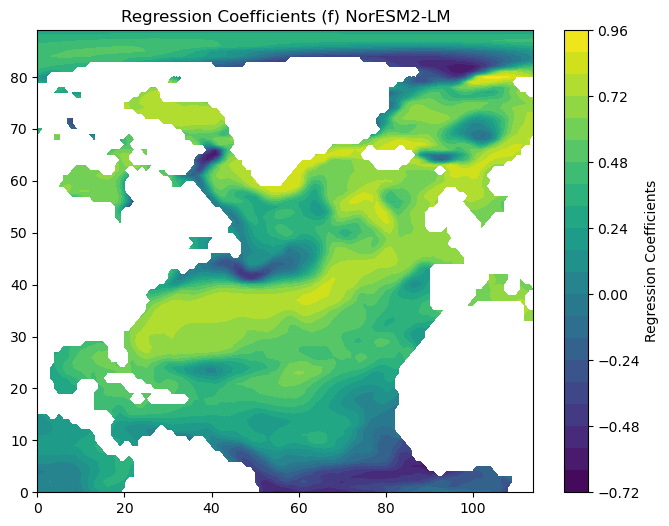

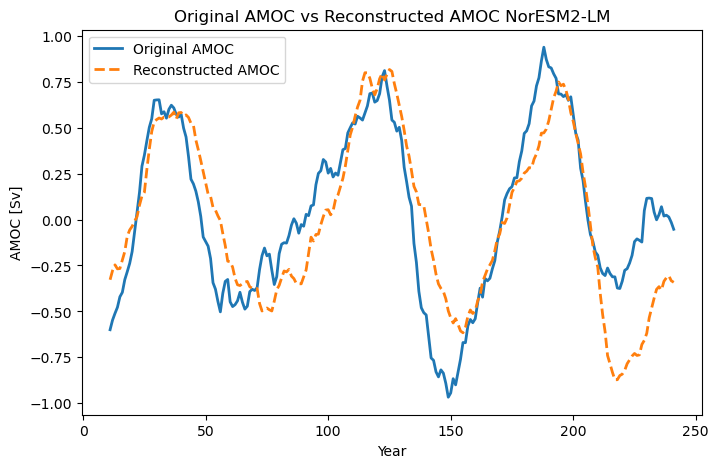

f range: -0.6459 to 0.9302
AMOC range: -0.9672 to 0.9381
Reconstructed AMOC range: -0.8722 to 0.8168
NorESM2-MM
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/NorESM2-MM_231yrs.nc


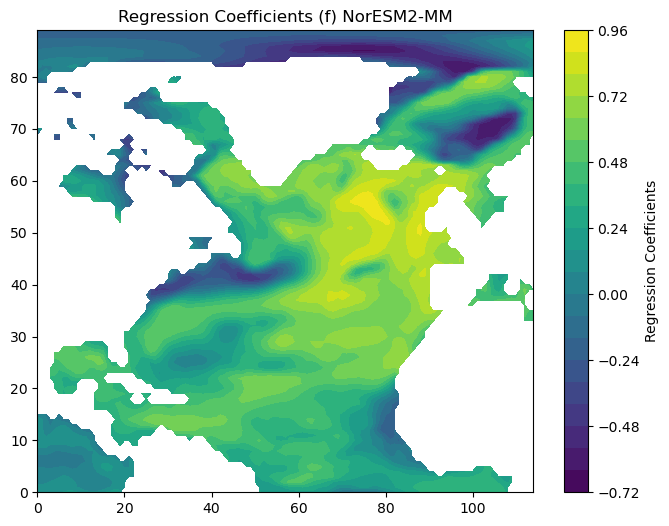

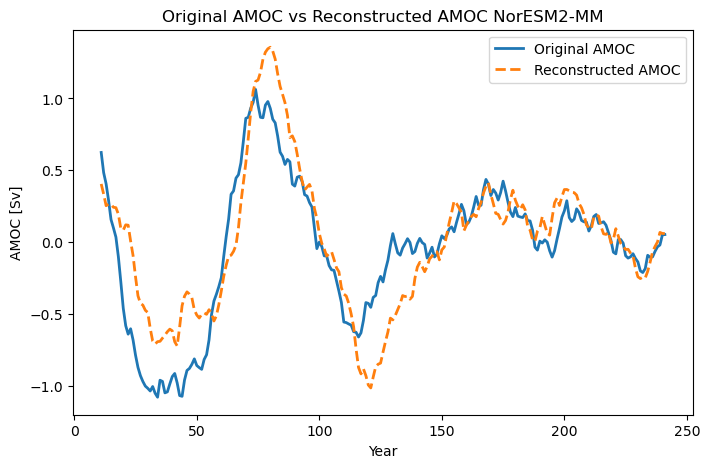

f range: -0.6548 to 0.9340
AMOC range: -1.0787 to 1.0630
Reconstructed AMOC range: -1.0141 to 1.3566
UKESM1-0-LL
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/UKESM1-0-LL_231yrs.nc


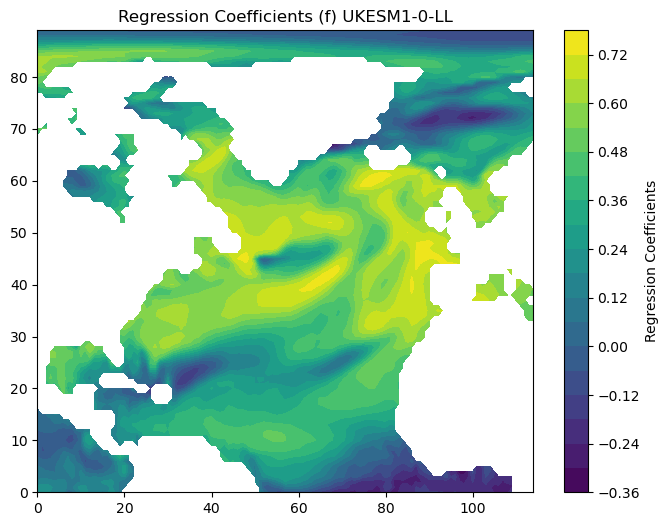

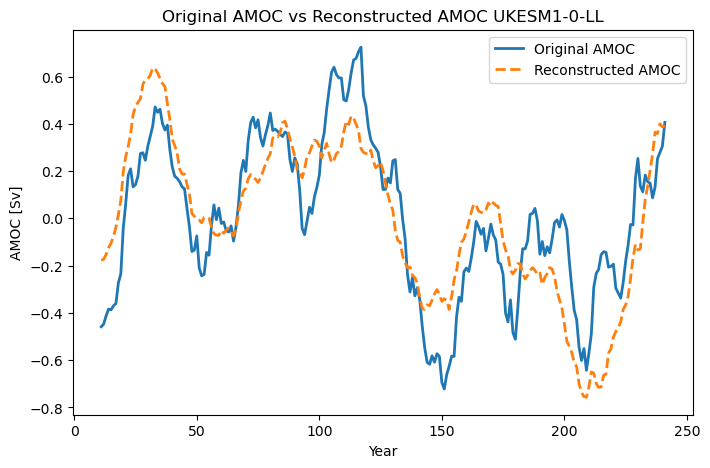

f range: -0.3588 to 0.7522
AMOC range: -0.7220 to 0.7242
Reconstructed AMOC range: -0.7568 to 0.6368


In [8]:
for i, model in enumerate(model_names):
    filename_amoc = PATH_AMOC + 'amoc_' + scenario + '_' + amoc_institution_names[i] + '_' + model + '_' + ens_members_appendices[i] + '.nc'
    filename_sst = PATH_SST + 'tos_Omon_' + model + '_' + scenario + '_' + ens_members_appendices[i] + '.nc'
    if os.path.exists(filename_amoc) and os.path.exists(filename_sst):

        print(model)
        
        sst_time_series = xr.open_dataset(filename_sst)['tos'].sel(lat = slice(lat_min, lat_max), lon = slice(lon_min, lon_max))
        sst_time_series['year'] = xr.DataArray(np.arange(1, len(sst_time_series['year'].values)+1), dims = 'year')
        sst_mean = sst_time_series.mean('year')
        sst_smoothed = (sst_time_series - sst_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')

        sst = sst_smoothed

        if model == 'IPSL-CM6A-LR':
            amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)), x = 0)
        else:
            amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)))
            
        amoc_mean = amoc_time_series.mean('year')
        amoc_smoothed = (amoc_time_series - amoc_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')
        amoc_smoothed['year'] = xr.DataArray(np.arange(1, len(amoc_smoothed['year'].values)+1), dims = 'year')

        amoc = amoc_smoothed

        # Get spatial grid dimensions for the North Atlantic region
        ny = sst.mean('year').shape[0]
        nx = sst.mean('year').shape[1]
    
        # Prepare and normalize data    
        sst_normalized = prepare_and_normalize_sst(sst)
        amoc, amoc_normalized, amoc_mean, amoc_std = prepare_and_normalize_amoc(amoc)
    
        # Train regression and reconstruct AMOC
        f, amoc_reconstructed = train_regression_and_reconstruct(sst_normalized, amoc_normalized, amoc_std)

        save_regression_map_sst_amoc_to_file(f, ny, nx, sst_smoothed, sst_normalized, amoc_normalized, amoc_std, amoc_reconstructed, model, PATH_saved_regressions, smoothing_period = running_mean_window)
    
        # Plot regression coefficients
        plot_regression_coefficients(f, ny, nx, f"Regression Coefficients (f) " + model)
    
        # Plot AMOC comparison
        plot_amoc_comparison(amoc, amoc_reconstructed,
                             f"Original AMOC vs Reconstructed AMOC " + model, smoothing_period = running_mean_window)
    
        # Debugging information
        print(f"f range: {np.min(f):.4f} to {np.max(f):.4f}")
        print(f"AMOC range: {np.min(amoc):.4f} to {np.max(amoc):.4f}")
        print(f"Reconstructed AMOC range: {np.min(amoc_reconstructed):.4f} to {np.max(amoc_reconstructed):.4f}")


# For each model, reconstruct AMOC based on every possible regression pattern 


ACCESS-CM2


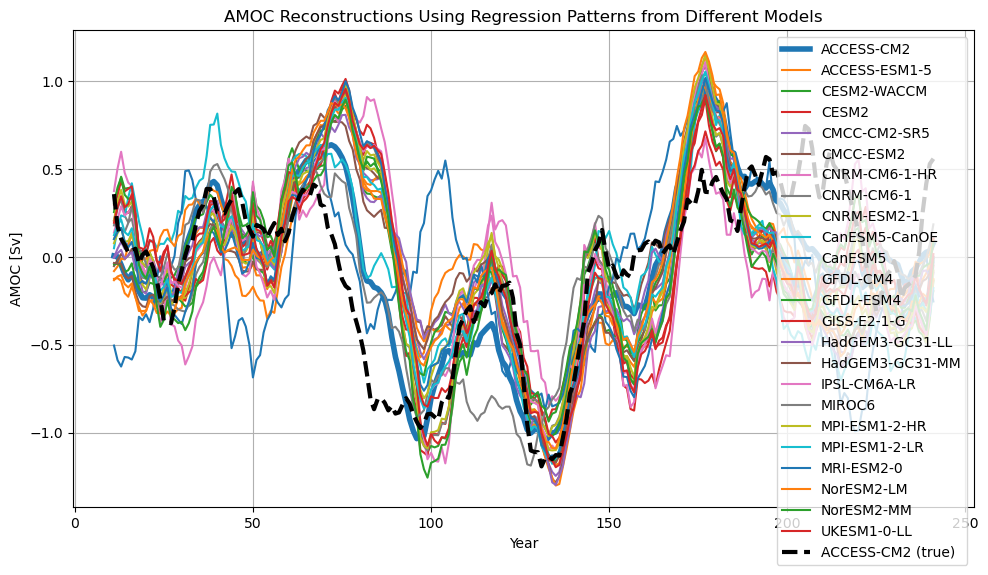

ACCESS-ESM1-5


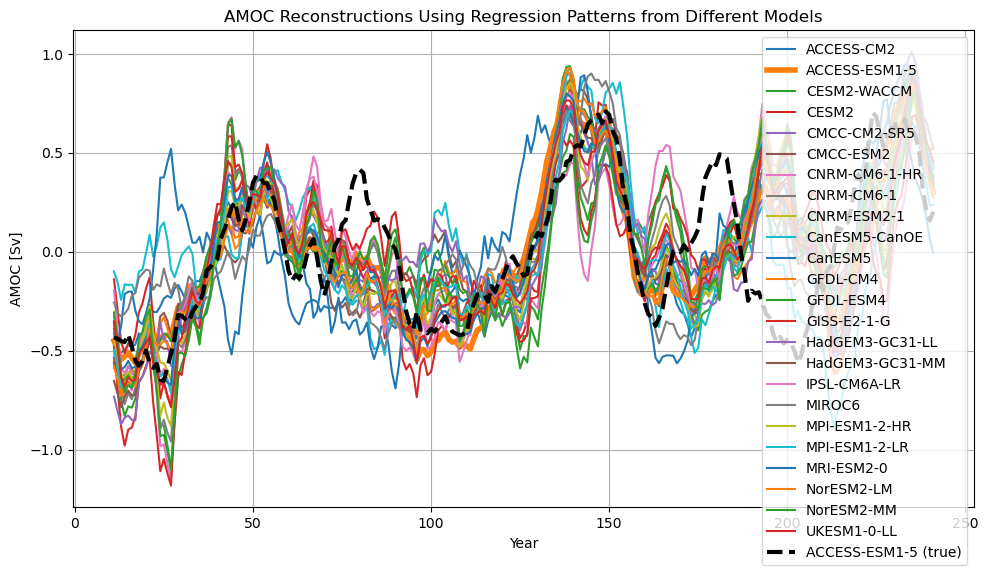

CESM2-WACCM


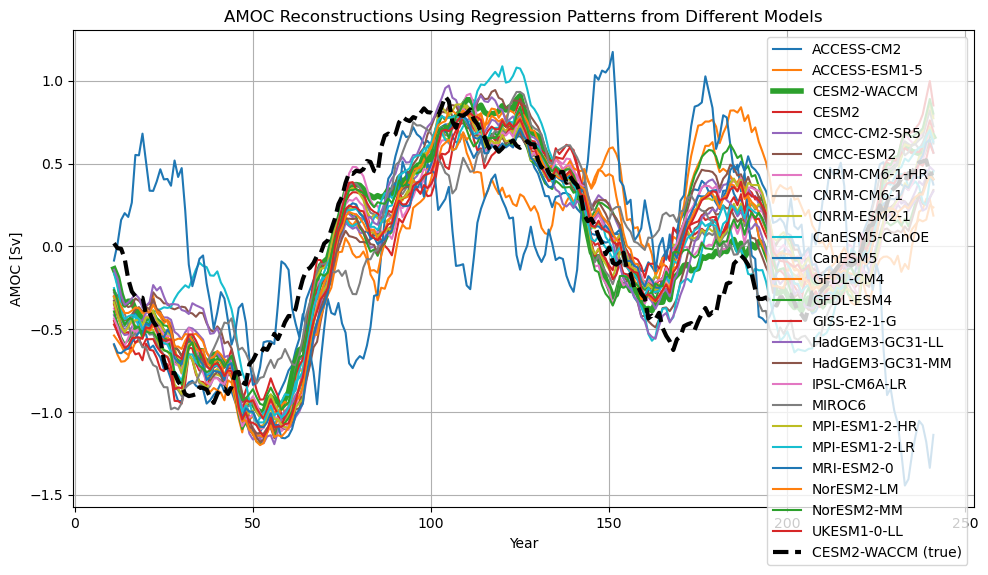

CESM2


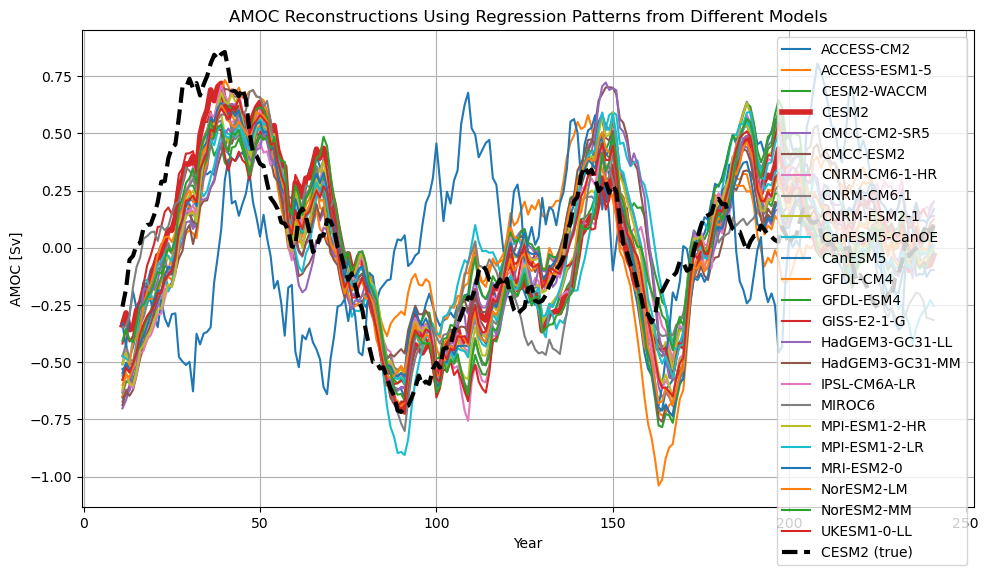

CMCC-CM2-SR5


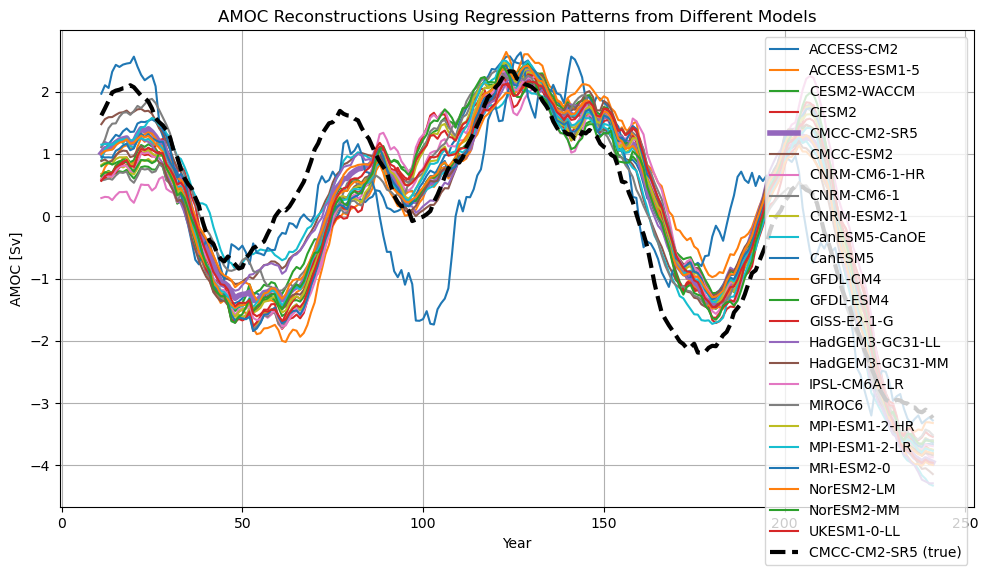

CMCC-ESM2


In [ ]:
for i, model in enumerate(model_names):
    filename_amoc = PATH_AMOC + 'amoc_' + scenario + '_' + amoc_institution_names[i] + '_' + model + '_' + ens_members_appendices[i] + '.nc'
    filename_sst = PATH_SST + 'tos_Omon_' + model + '_' + scenario + '_' + ens_members_appendices[i] + '.nc'
    if os.path.exists(filename_amoc) and os.path.exists(filename_sst):

        print(model)
        
        sst_time_series = xr.open_dataset(filename_sst)['tos'].sel(lat = slice(lat_min, lat_max), lon = slice(lon_min, lon_max))
        sst_time_series['year'] = xr.DataArray(np.arange(1, len(sst_time_series['year'].values)+1), dims = 'year')
        sst_mean = sst_time_series.mean('year')
        sst_smoothed = (sst_time_series - sst_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')

        sst = sst_smoothed

        sst_normalized = prepare_and_normalize_sst(sst)

        # Get spatial grid dimensions for the North Atlantic region
        ny = sst.mean('year').shape[0]
        nx = sst.mean('year').shape[1]

        if model == 'IPSL-CM6A-LR':
            amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)), x = 0)
        else:
            amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)))
            
        amoc_mean = amoc_time_series.mean('year')
        amoc_smoothed = (amoc_time_series - amoc_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')
        amoc_smoothed['year'] = xr.DataArray(np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1), dims = 'year')

        amoc = amoc_smoothed

        # Get spatial grid dimensions for the North Atlantic region
        ny = sst.mean('year').shape[0]
        nx = sst.mean('year').shape[1]
    
        # Prepare and normalize data    
        sst_normalized = prepare_and_normalize_sst(sst)
        amoc, amoc_normalized, amoc_mean, amoc_std = prepare_and_normalize_amoc(amoc)

        amoc_recon_with_regressions_from_different_models = xr.Dataset()
        
        for imr, model_regr in enumerate(model_names):
            regression_pattern = xr.open_dataset(PATH_saved_regressions + model_regr + '_231yrs.nc').fr.fillna(0).values.flatten()

            amoc_reconstructed = sst_normalized @ regression_pattern
            amoc_reconstructed = amoc_reconstructed * amoc_std / np.std(amoc_reconstructed) + amoc_mean
            # amoc_reconstructions.append(amoc_reconstructed)

            amoc_recon_with_regressions_from_different_models[model_regr] = xr.DataArray(amoc_reconstructed,
                                                                                         dims=["year"],
                                                                                         coords={"year": np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1)},
                                                                                         name=model_regr)
        
        amoc_recon_with_regressions_from_different_models.to_netcdf(PATH_saved_cross_regressions + '/SST_from_' + model + '_regression_patterns_from_all_models.nc')
        plt.figure(figsize=(10, 6))

        for model_regr in amoc_recon_with_regressions_from_different_models.data_vars:
            if model_regr == model:
                da = amoc_recon_with_regressions_from_different_models[model_regr]
                plt.plot(da["year"], da, label=model_regr, linewidth = 4)
            else:
                da = amoc_recon_with_regressions_from_different_models[model_regr]
                plt.plot(da["year"], da, label=model_regr)

        plt.plot(amoc_smoothed['year'], amoc_smoothed, label = model + ' (true)', color='black', linewidth=3, linestyle='--')
        
                
        
        plt.title("AMOC Reconstructions Using Regression Patterns from Different Models")
        plt.xlabel("Year")
        plt.ylabel("AMOC [Sv]")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()